In [1]:
import magritte.core  as magritte             # Core functionality
import numpy as np
import os
import yt
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rc('font', family='serif')

from scipy.spatial import Delaunay, cKDTree   # Finding neighbors

In [2]:
#wdir = "/lhome/thomasc/Magritte-examples/Comoving/Phantom_3D_fullNLTE/"
wdir = "/STER/thomasc/Magritte_comoving_adaptiverays/Magritte-examples/Phantom_3D_more_refinement"
J_file_feautrier = os.path.join(wdir, 'J_feautrier.npy')
J_file_comoving = os.path.join(wdir, 'J_comoving.npy')
J_file_comapp = os.path.join(wdir, 'J_comapp.npy')
J_file_shortchar = os.path.join(wdir, 'J_shortchar.npy')
model_file_rec = os.path.join(wdir, 'wind_red_rec.hdf5')   # reduced 3D Phantom Magritte model
model_file_original = os.path.join(wdir, 'model_Phantom_3D_for_comoving.hdf5')   # reduced 3D Phantom Magritte model

J_file_original_comoving = os.path.join(wdir, 'J_original_comoving.npy')
J_file_original_feautrier = os.path.join(wdir, 'J_original_feautrier.npy')
J_file_original_comapp = os.path.join(wdir, 'J_original_comapp.npy')

NLTE_J_file_feaut = os.path.join(wdir, 'NLTE_J_rec.npy')
NLTE_J_file_comoving = os.path.join(wdir, 'NLTE_J_comoving.npy')
NLTE_J_file_comapp = os.path.join(wdir, 'NLTE_J_comoving_approx.npy')

#also load for the uniform discretization
wdir_unif = "/STER/thomasc/Magritte_comoving/Magritte-examples/Phantom_3D_fullNLTE"
J_file_feautrier_unif = os.path.join(wdir_unif, 'J_feautrier.npy')
J_file_comoving_unif = os.path.join(wdir_unif, 'J_comoving.npy')
J_file_comapp_unif = os.path.join(wdir_unif, 'J_comapp.npy')

J_file_original_comoving_unif = os.path.join(wdir_unif, 'J_original_comoving.npy')
J_file_original_feautrier_unif = os.path.join(wdir_unif, 'J_original_feautrier.npy')
J_file_original_comapp_unif = os.path.join(wdir_unif, 'J_original_comapp.npy')

NLTE_J_file_feaut_unif = os.path.join(wdir_unif, 'NLTE_J_rec.npy')
NLTE_J_file_comoving_unif = os.path.join(wdir_unif, 'NLTE_J_comoving.npy')
NLTE_J_file_comapp_unif = os.path.join(wdir_unif, 'NLTE_J_comoving_approx.npy')


# J_file_feautrier_2lines = os.path.join(wdir, 'J_feautrier_2lines.npy')
# J_file_comoving_2lines = os.path.join(wdir, 'J_comoving_2lines.npy')
# J_file_shortchar_2lines = os.path.join(wdir, 'J_shortchar_2lines.npy')

Loading the different saved J's for comparing them

In [3]:
J_feautrier = np.load(J_file_feautrier)[:,1]
J_comoving = np.load(J_file_comoving)[:,1]
J_comapp = np.load(J_file_comapp)[:,1]
#J_shortchar = np.load(J_file_shortchar)[:,1]

J_feautrier_original = np.load(J_file_original_feautrier)[:,1]
J_comoving_original = np.load(J_file_original_comoving)[:,1]
J_comapp_original = np.load(J_file_original_comapp)[:,1]

NLTE_J_feautrier = np.load(NLTE_J_file_feaut)[:,1]
NLTE_J_comoving = np.load(NLTE_J_file_comoving)[:,1]
NLTE_J_comapp = np.load(NLTE_J_file_comapp)[:,1]

J_feautrier_original_unif = np.load(J_file_original_feautrier_unif)[:,1]
J_comoving_original_unif = np.load(J_file_original_comoving_unif)[:,1]
J_comapp_original_unif = np.load(J_file_original_comapp_unif)[:,1]

NLTE_J_feautrier_unif = np.load(NLTE_J_file_feaut_unif)[:,1]
NLTE_J_comoving_unif = np.load(NLTE_J_file_comoving_unif)[:,1]
NLTE_J_comapp_unif = np.load(NLTE_J_file_comapp_unif)[:,1]

# J_feautrier_l0 = np.load(J_file_feautrier_2lines)[:,0]
# J_comoving_l0 = np.load(J_file_comoving_2lines)[:,0]
# J_shortchar_l0 = np.load(J_file_shortchar_2lines)[:,0]

# J_feautrier_l1 = np.load(J_file_feautrier_2lines)[:,1]
# J_comoving_l1 = np.load(J_file_comoving_2lines)[:,1]
# J_shortchar_l1 = np.load(J_file_shortchar_2lines)[:,1]



In [4]:
print(J_feautrier.shape)
print(J_comoving.shape)
print(J_comapp.shape)
#print(J_shortchar.shape)

(52258,)
(52258,)
(52258,)


Load all models again in order to obtain the corresponding grids.

In [5]:
model_rec = magritte.Model(model_file_rec)
model_original = magritte.Model(model_file_original)

                                           
-------------------------------------------
  Reading Model...                         
-------------------------------------------
 model file = /STER/thomasc/Magritte_comoving_adaptiverays/Magritte-examples/Phantom_3D_more_refinement/wind_red_rec.hdf5
-------------------------------------------
Reading parameters...
Reading points...
Reading rays...
Reading boundary...
Reading chemistry...
Reading species...
Reading thermodynamics...
Reading temperature...
Reading turbulence...
Reading lines...
Reading lineProducingSpecies...
Reading linedata...
read num 1
read sym CO
nlev = 41
nrad = 40
Reading collisionPartner...
Reading collisionPartner...
Reading quadrature...
Reading radiation...
Reading frequencies...
Not using scattering!
                                           
-------------------------------------------
  Model read, parameters:                  
-------------------------------------------
  npoints    = 52258
  nrays      = 72


Obtain delaunay triangulations (might take a few minutes for the original grid)

In [6]:
position_rec = np.array(model_rec.geometry.points.position)
delaunay_rec = Delaunay(position_rec)
print(delaunay_rec)
position_original = np.array(model_original.geometry.points.position)
delaunay_original = Delaunay(position_original)
velocity_original = np.array(model_original.geometry.points.velocity)
#Deleting the model objects to free memory
del model_rec
del model_original

Plot the velocity field

In [7]:
import astropy.constants as constants
#computing the radial velocity
radial_velocity = np.sum(velocity_original*constants.c.si.value*position_original/np.linalg.norm(position_original, axis=1)[:, None], axis=1)#in m/s
velocity_norm = np.linalg.norm(velocity_original, axis=1)*constants.c.si.value
print(radial_velocity, len(radial_velocity), len(position_original))

ds_rv = yt.load_unstructured_mesh(
    connectivity = delaunay_original.simplices.astype(np.int64),
    coordinates  = delaunay_original.points.astype(np.float64), # yt expects cm not m; err we can also specify the length unit
    node_data    = {('connect1', '||v||'): velocity_norm[delaunay_original.simplices].astype(np.float64)*yt.units.m/ yt.units.s, 
                    ('connect1', 'velocity_x'): velocity_original[:, 0][delaunay_original.simplices].astype(np.float64)*yt.units.m/ yt.units.s, 
                    ('connect1', 'velocity_y'): velocity_original[:, 1][delaunay_original.simplices].astype(np.float64)*yt.units.m/ yt.units.s,
                    ('connect1', 'velocity_z'): velocity_original[:, 2][delaunay_original.simplices].astype(np.float64)*yt.units.m/ yt.units.s},
    length_unit='m'
)

sl = yt.SlicePlot (ds_rv, 'z', [('connect1', '||v||')])
sl.set_cmap       (('connect1', '||v||'), 'magma')
#sl.set_zlim(('connect1', 'n'), zmin=(0, 'm/s'), zmax=(2e+4, 'm/s'))
sl.annotate_velocity(24, normalize=True, scale=48, color="white")
sl.set_log(("connect1", "||v||"), False)
sl.zoom(2.5)
sl.save("radial_velocity_zoom.pdf")

[11852.32019114 13484.4277033  13453.64403666 ... 10238.99907763
 10976.10938908 11594.12772648] 885501 885501


yt : [INFO     ] 2025-01-14 12:58:03,524 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-01-14 12:58:03,526 Parameters: domain_dimensions         = [2 2 2]
yt : [INFO     ] 2025-01-14 12:58:03,527 Parameters: domain_left_edge          = [-4.10031269e+13 -4.10031269e+13 -4.09575680e+13]
yt : [INFO     ] 2025-01-14 12:58:03,528 Parameters: domain_right_edge         = [4.10031269e+13 4.10031269e+13 4.09575680e+13]
yt : [INFO     ] 2025-01-14 12:58:03,529 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-01-14 12:58:04,455 xlim = -41003126946201.890625 41003126946201.890625
yt : [INFO     ] 2025-01-14 12:58:04,456 ylim = -41003126946201.890625 41003126946201.890625
yt : [INFO     ] 2025-01-14 12:58:04,460 xlim = -41003126946201.890625 41003126946201.890625
yt : [INFO     ] 2025-01-14 12:58:04,461 ylim = -41003126946201.890625 41003126946201.890625
yt : [INFO     ] 2025-01-14 12:58:04,468 Making a fixed resolution buffer of (('connect1', '||v||')) 800 by 800


['radial_velocity_zoom.pdf']

Plot all computed J's on the reduced grids

In [8]:
ds_feautrier = yt.load_unstructured_mesh(
    connectivity = delaunay_rec.simplices.astype(np.int64),
    coordinates  = delaunay_rec.points.astype(np.float64) * 100.0, # yt expects cm not m 
    node_data    = {('connect1', 'J'): J_feautrier[delaunay_rec.simplices].astype(np.float64)}
)

yt : [INFO     ] 2025-01-14 12:58:12,580 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-01-14 12:58:12,581 Parameters: domain_dimensions         = [2 2 2]
yt : [INFO     ] 2025-01-14 12:58:12,583 Parameters: domain_left_edge          = [-4.10031269e+15 -4.10031269e+15 -4.09575680e+15]
yt : [INFO     ] 2025-01-14 12:58:12,584 Parameters: domain_right_edge         = [4.10031269e+15 4.10031269e+15 4.09575680e+15]
yt : [INFO     ] 2025-01-14 12:58:12,585 Parameters: cosmological_simulation   = 0


yt : [INFO     ] 2025-01-14 12:58:12,773 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 12:58:12,775 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 12:58:12,779 xlim = -4100312694620189.000000 4100312694620189.000000


yt : [INFO     ] 2025-01-14 12:58:12,780 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 12:58:12,783 Making a fixed resolution buffer of (('connect1', 'J')) 800 by 800



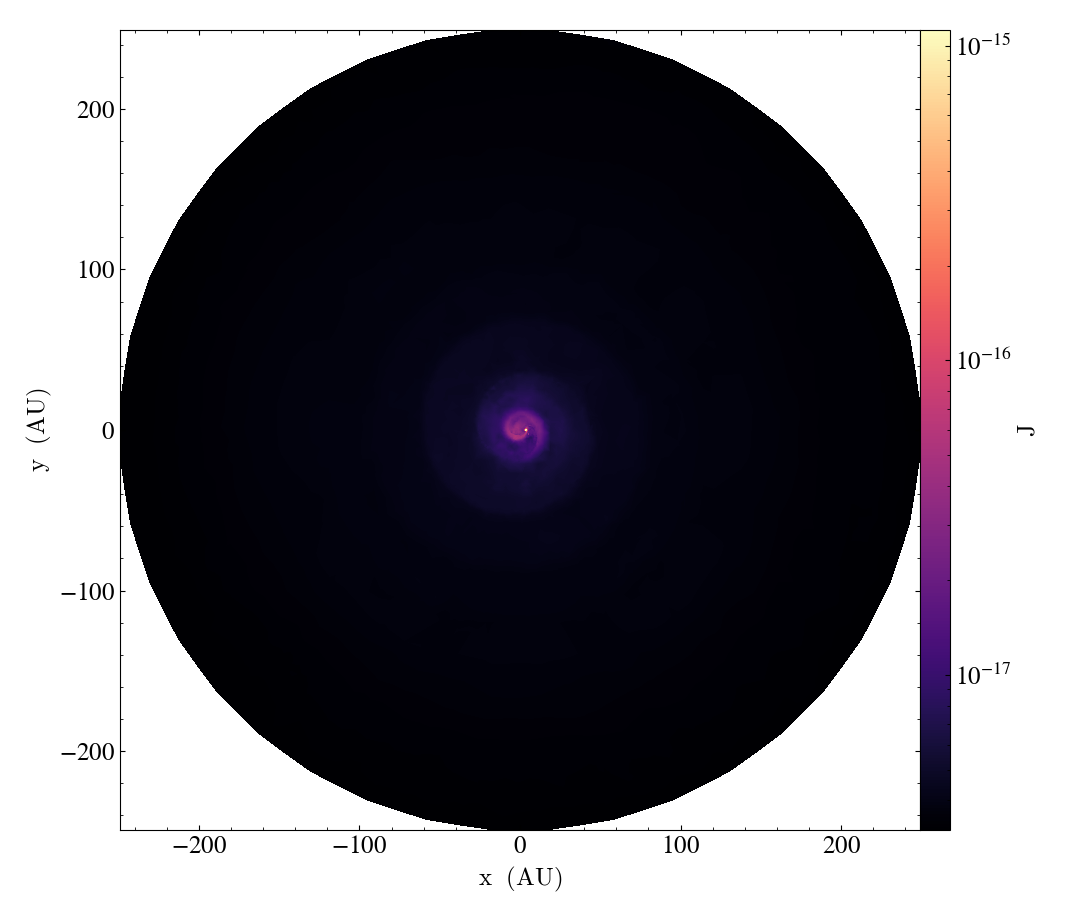

In [9]:
sl = yt.SlicePlot (ds_feautrier, 'z', ('connect1','J'))
sl.set_cmap       (('connect1', 'J'), 'magma')
#sl.set_zlim(('connect1', 'n'), zmin=(1e+6, "1"), zmax=(1e+12, "1"))
sl.zoom           (1.1)

yt : [INFO     ] 2025-01-14 12:58:14,934 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-01-14 12:58:14,936 Parameters: domain_dimensions         = [2 2 2]
yt : [INFO     ] 2025-01-14 12:58:14,936 Parameters: domain_left_edge          = [-4.10031269e+15 -4.10031269e+15 -4.09575680e+15]
yt : [INFO     ] 2025-01-14 12:58:14,937 Parameters: domain_right_edge         = [4.10031269e+15 4.10031269e+15 4.09575680e+15]
yt : [INFO     ] 2025-01-14 12:58:14,938 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-01-14 12:58:15,095 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 12:58:15,096 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 12:58:15,100 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 12:58:15,101 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 12:58:15,104 Making a fixed resolution buffer of (('connect1', 'J'))


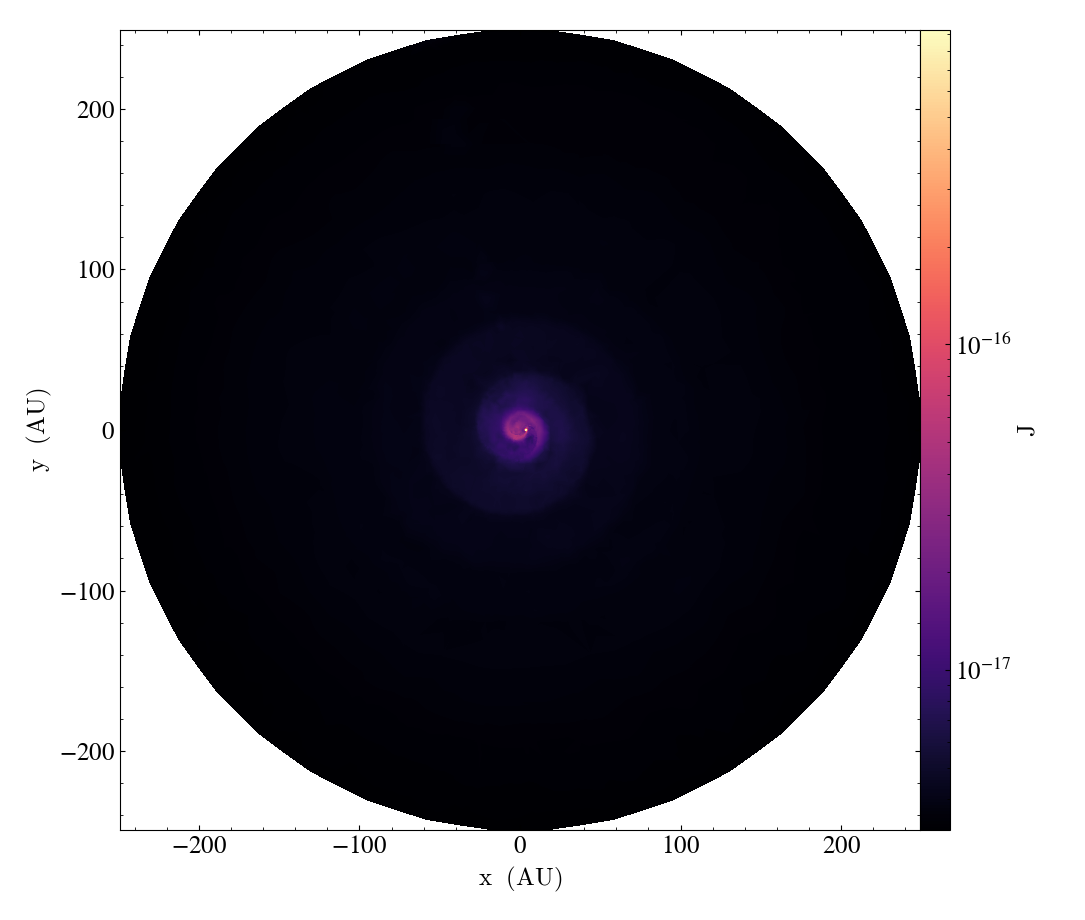

In [10]:
ds_comoving = yt.load_unstructured_mesh(
    connectivity = delaunay_rec.simplices.astype(np.int64),
    coordinates  = delaunay_rec.points.astype(np.float64) * 100.0, # yt expects cm not m 
    node_data    = {('connect1', 'J'): J_comoving[delaunay_rec.simplices].astype(np.float64)}
)
sl = yt.SlicePlot (ds_comoving, 'z', ('connect1','J'))
sl.set_cmap       (('connect1', 'J'), 'magma')
#sl.set_zlim(('connect1', 'n'), zmin=(1e+6, "1"), zmax=(1e+12, "1"))
sl.zoom           (1.1)

yt : [INFO     ] 2025-01-14 12:58:17,063 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-01-14 12:58:17,064 Parameters: domain_dimensions         = [2 2 2]
yt : [INFO     ] 2025-01-14 12:58:17,065 Parameters: domain_left_edge          = [-4.10031269e+15 -4.10031269e+15 -4.09575680e+15]
yt : [INFO     ] 2025-01-14 12:58:17,066 Parameters: domain_right_edge         = [4.10031269e+15 4.10031269e+15 4.09575680e+15]
yt : [INFO     ] 2025-01-14 12:58:17,067 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-01-14 12:58:17,225 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 12:58:17,226 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 12:58:17,229 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 12:58:17,230 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 12:58:17,233 Making a fixed resolution buffer of (('connect1', 'J'))


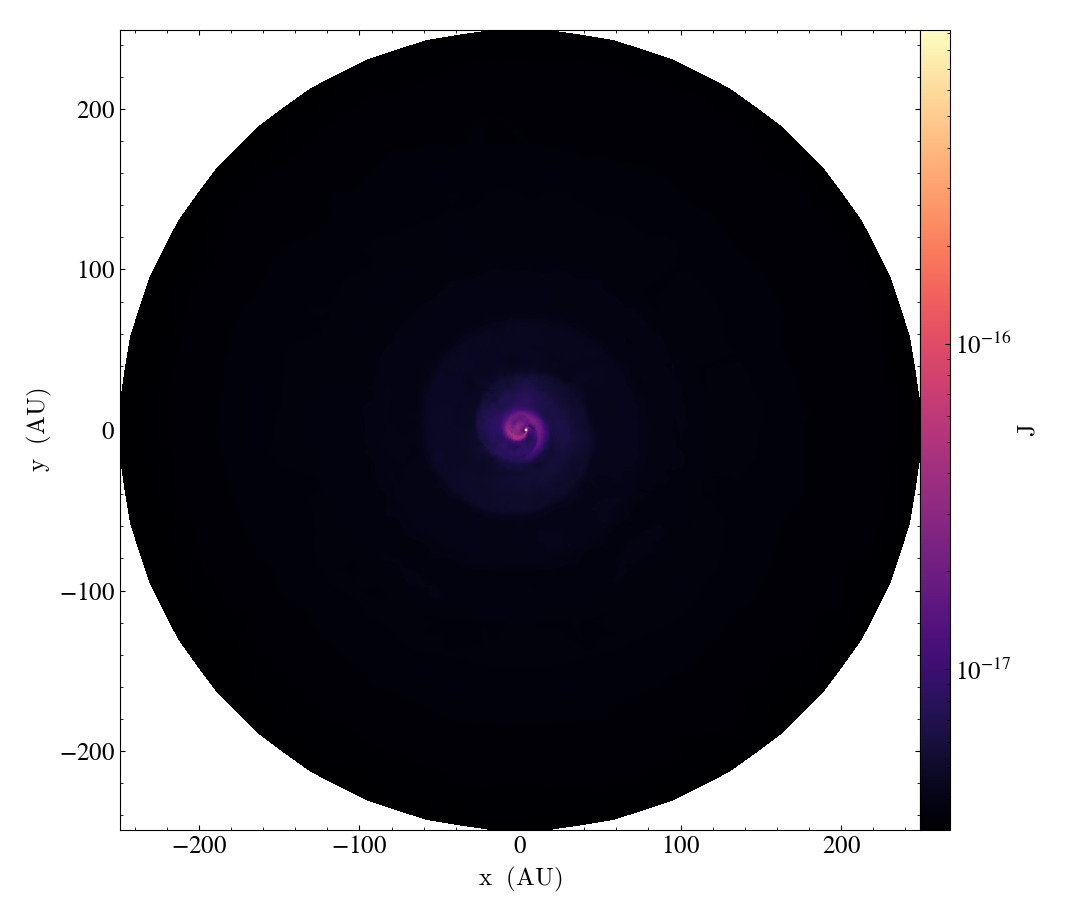

In [11]:
ds_comapp = yt.load_unstructured_mesh(
    connectivity = delaunay_rec.simplices.astype(np.int64),
    coordinates  = delaunay_rec.points.astype(np.float64) * 100.0, # yt expects cm not m 
    node_data    = {('connect1', 'J'): J_comapp[delaunay_rec.simplices].astype(np.float64)}
)
sl = yt.SlicePlot (ds_comapp, 'z', ('connect1','J'))
sl.set_cmap       (('connect1', 'J'), 'magma')
# sl.set_zlim(('connect1', 'J'), zmin=(1e-16, "1"), zmax=(2e-14, "1"))
sl.zoom           (1.1)

In [12]:
#ds_shortchar = yt.load_unstructured_mesh(
#    connectivity = delaunay_rec.simplices.astype(np.int64),
#    coordinates  = delaunay_rec.points.astype(np.float64) * 100.0, # yt expects cm not m 
#    node_data    = {('connect1', 'J'): J_shortchar[delaunay_rec.simplices].astype(np.float64)}
#)
#sl = yt.SlicePlot (ds_shortchar, 'z', ('connect1','J'))
#sl.set_cmap       (('connect1', 'J'), 'magma')
##sl.set_zlim(('connect1', 'n'), zmin=(1e+6, "1"), zmax=(1e+12, "1"))
#sl.zoom           (1.1)

and now the solvers on the original grid

yt : [INFO     ] 2025-01-14 12:58:19,870 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-01-14 12:58:19,871 Parameters: domain_dimensions         = [2 2 2]
yt : [INFO     ] 2025-01-14 12:58:19,872 Parameters: domain_left_edge          = [-4.10031269e+15 -4.10031269e+15 -4.09575680e+15]
yt : [INFO     ] 2025-01-14 12:58:19,873 Parameters: domain_right_edge         = [4.10031269e+15 4.10031269e+15 4.09575680e+15]
yt : [INFO     ] 2025-01-14 12:58:19,875 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-01-14 12:58:20,446 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 12:58:20,447 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 12:58:20,451 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 12:58:20,453 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 12:58:20,456 Making a fixed resolution buffer of (('connect1', 'J'))


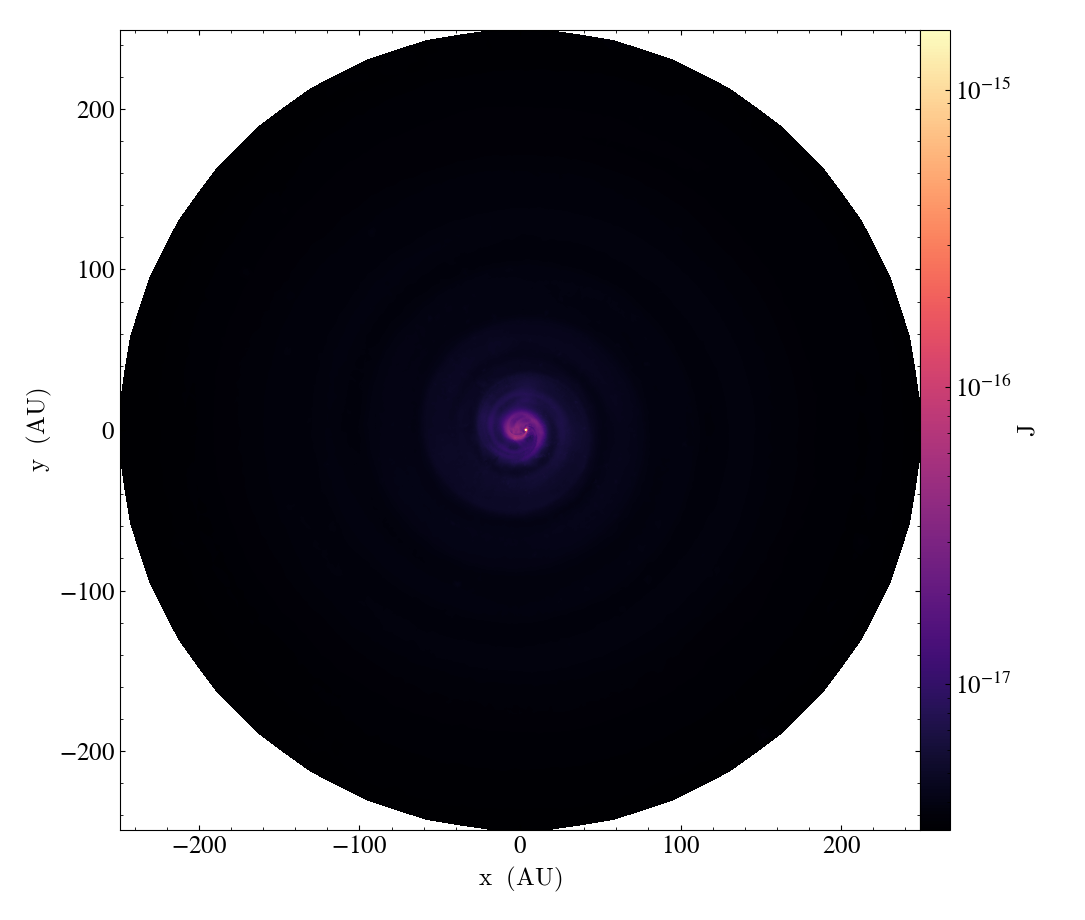

In [13]:
ds_feautrier_original = yt.load_unstructured_mesh(
    connectivity = delaunay_original.simplices.astype(np.int64),
    coordinates  = delaunay_original.points.astype(np.float64) * 100.0, # yt expects cm not m 
    node_data    = {('connect1', 'J'): J_feautrier_original[delaunay_original.simplices].astype(np.float64)}
)
sl = yt.SlicePlot (ds_feautrier_original, 'z', ('connect1','J'))
sl.set_cmap       (('connect1', 'J'), 'magma')
#sl.set_zlim(('connect1', 'n'), zmin=(1e+6, "1"), zmax=(1e+12, "1"))
sl.zoom           (1.1)

yt : [INFO     ] 2025-01-14 12:58:25,616 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-01-14 12:58:25,617 Parameters: domain_dimensions         = [2 2 2]
yt : [INFO     ] 2025-01-14 12:58:25,619 Parameters: domain_left_edge          = [-4.10031269e+15 -4.10031269e+15 -4.09575680e+15]
yt : [INFO     ] 2025-01-14 12:58:25,620 Parameters: domain_right_edge         = [4.10031269e+15 4.10031269e+15 4.09575680e+15]
yt : [INFO     ] 2025-01-14 12:58:25,621 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-01-14 12:58:26,258 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 12:58:26,259 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 12:58:26,263 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 12:58:26,264 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 12:58:26,267 Making a fixed resolution buffer of (('connect1', 'J'))


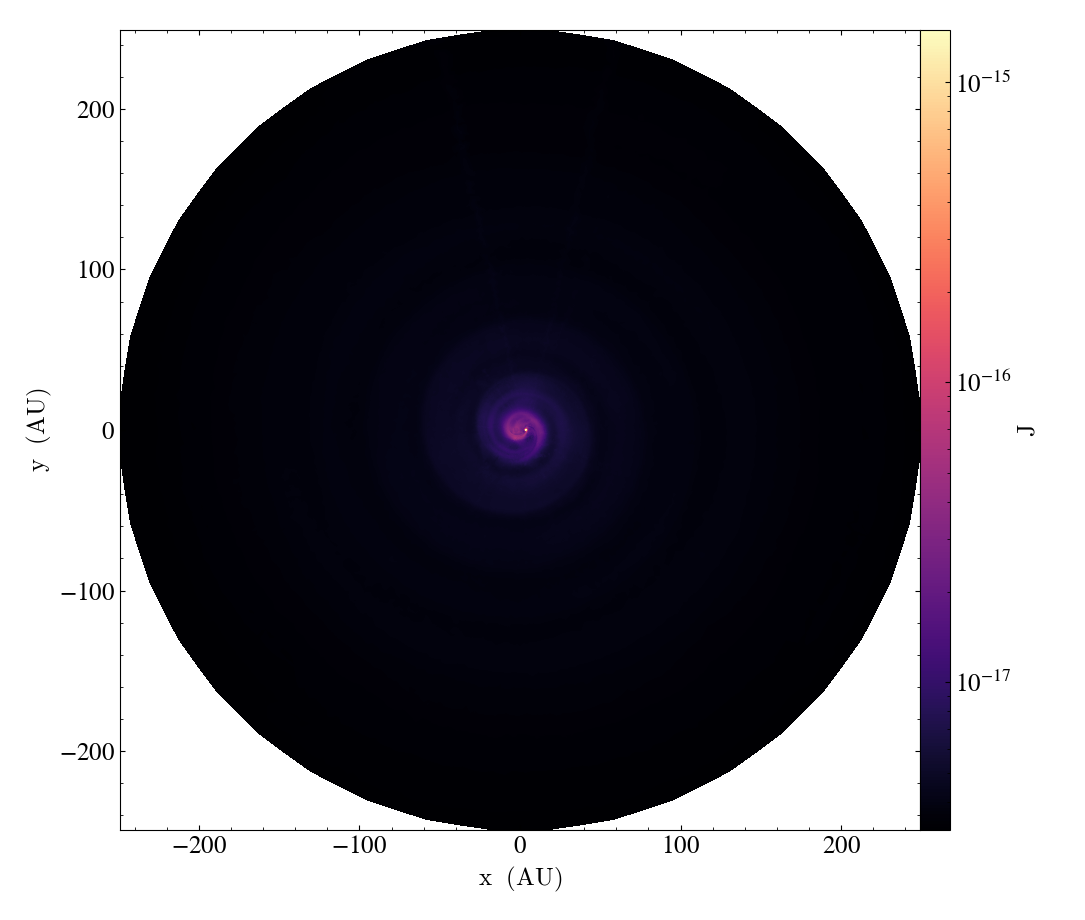

In [14]:
ds_comoving_original = yt.load_unstructured_mesh(
    connectivity = delaunay_original.simplices.astype(np.int64),
    coordinates  = delaunay_original.points.astype(np.float64) * 100.0, # yt expects cm not m 
    node_data    = {('connect1', 'J'): J_comoving_original[delaunay_original.simplices].astype(np.float64)}
)
sl = yt.SlicePlot (ds_comoving_original, 'z', ('connect1','J'))
sl.set_cmap       (('connect1', 'J'), 'magma')
#sl.set_zlim(('connect1', 'n'), zmin=(1e+6, "1"), zmax=(1e+12, "1"))
sl.zoom           (1.1)

yt : [INFO     ] 2025-01-14 12:58:31,859 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-01-14 12:58:31,860 Parameters: domain_dimensions         = [2 2 2]
yt : [INFO     ] 2025-01-14 12:58:31,861 Parameters: domain_left_edge          = [-4.10031269e+15 -4.10031269e+15 -4.09575680e+15]
yt : [INFO     ] 2025-01-14 12:58:31,862 Parameters: domain_right_edge         = [4.10031269e+15 4.10031269e+15 4.09575680e+15]
yt : [INFO     ] 2025-01-14 12:58:31,863 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-01-14 12:58:32,433 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 12:58:32,435 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 12:58:32,439 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 12:58:32,440 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 12:58:32,443 Making a fixed resolution buffer of (('connect1', 'J'))


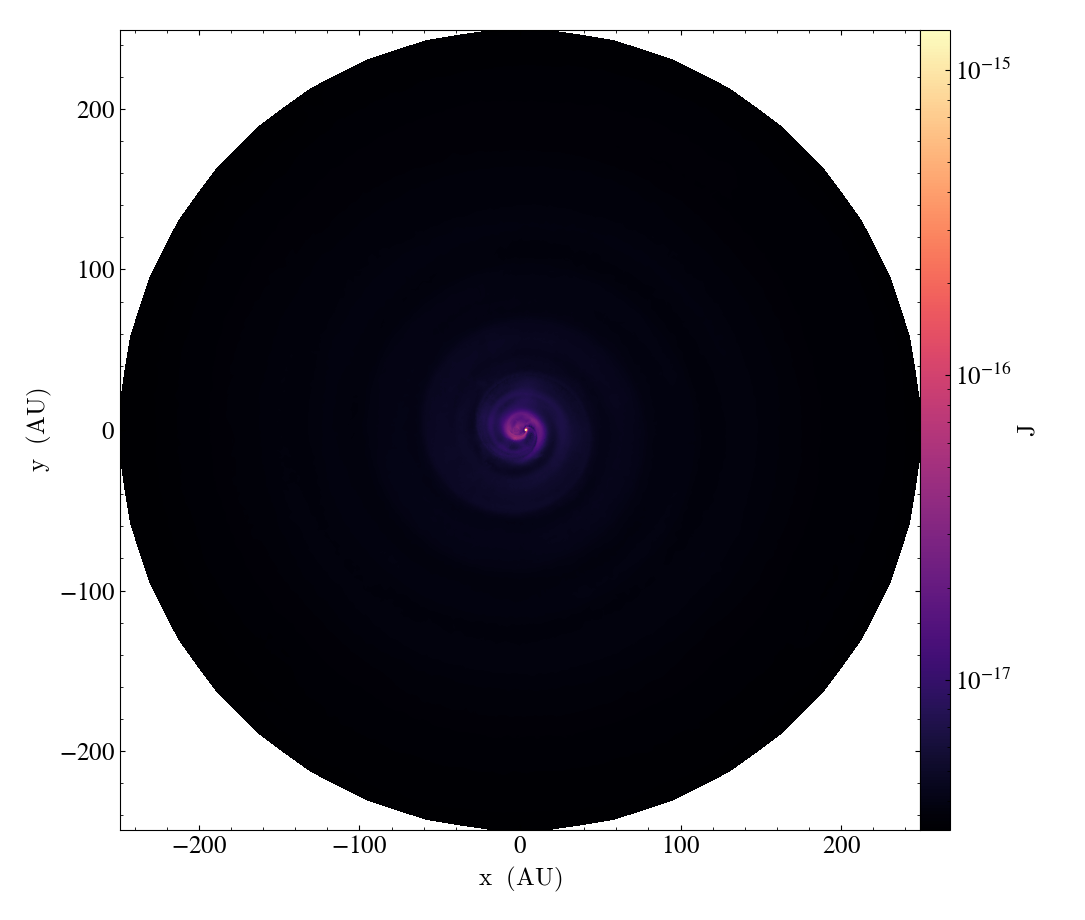

In [15]:
ds_comapp_original = yt.load_unstructured_mesh(
    connectivity = delaunay_original.simplices.astype(np.int64),
    coordinates  = delaunay_original.points.astype(np.float64) * 100.0, # yt expects cm not m 
    node_data    = {('connect1', 'J'): J_comapp_original[delaunay_original.simplices].astype(np.float64)}
)
sl = yt.SlicePlot (ds_comapp_original, 'z', ('connect1','J'))
sl.set_cmap       (('connect1', 'J'), 'magma')
#sl.set_zlim(('connect1', 'n'), zmin=(1e+6, "1"), zmax=(1e+12, "1"))
sl.zoom           (1.1)

Also plot NLTE J on original grid.

yt : [INFO     ] 2025-01-14 12:58:37,715 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-01-14 12:58:37,716 Parameters: domain_dimensions         = [2 2 2]
yt : [INFO     ] 2025-01-14 12:58:37,717 Parameters: domain_left_edge          = [-4.10031269e+15 -4.10031269e+15 -4.09575680e+15]
yt : [INFO     ] 2025-01-14 12:58:37,718 Parameters: domain_right_edge         = [4.10031269e+15 4.10031269e+15 4.09575680e+15]
yt : [INFO     ] 2025-01-14 12:58:37,719 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-01-14 12:58:38,295 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 12:58:38,296 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 12:58:38,300 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 12:58:38,300 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 12:58:38,303 Making a fixed resolution buffer of (('connect1', 'J'))


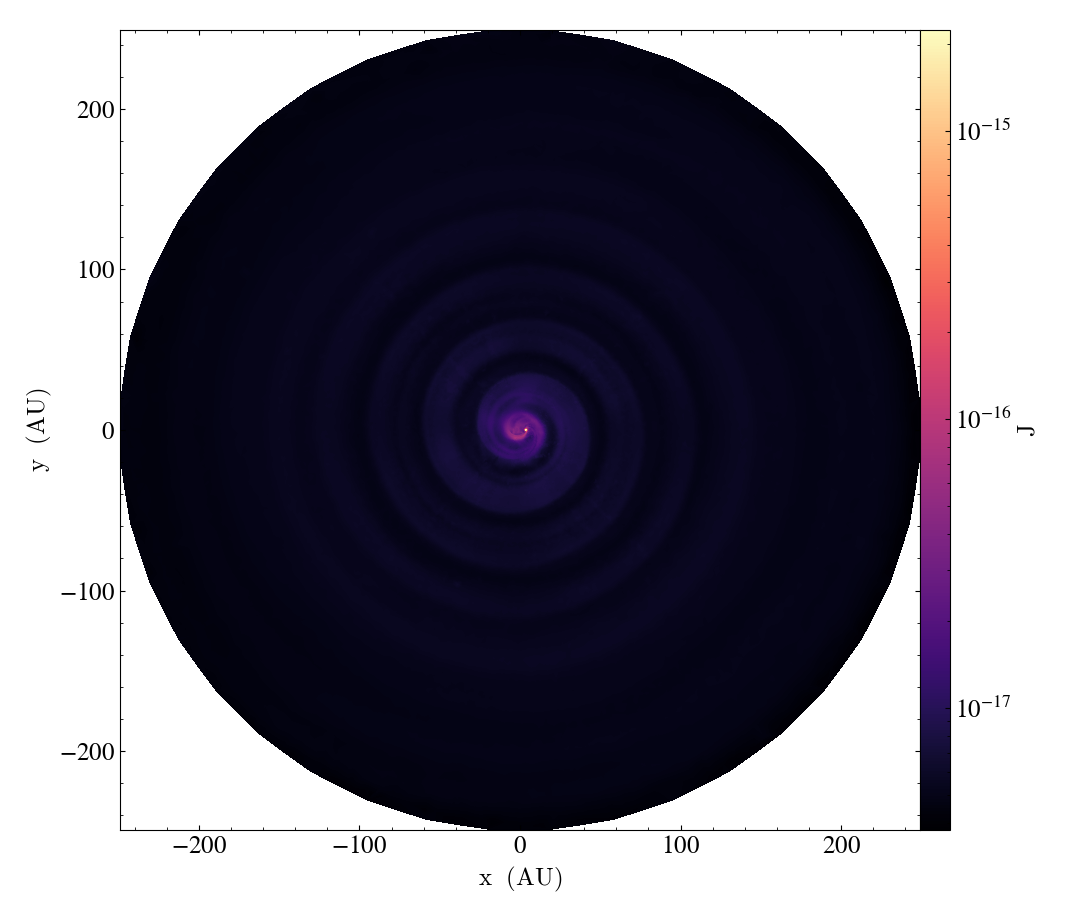

In [16]:
ds_NLTE_feautrier = yt.load_unstructured_mesh(
    connectivity = delaunay_original.simplices.astype(np.int64),
    coordinates  = delaunay_original.points.astype(np.float64) * 100.0, # yt expects cm not m 
    node_data    = {('connect1', 'J'): NLTE_J_feautrier[delaunay_original.simplices].astype(np.float64)}
)
sl = yt.SlicePlot (ds_NLTE_feautrier, 'z', ('connect1','J'))
sl.set_cmap       (('connect1', 'J'), 'magma')
# sl.set_zlim(('connect1', 'J'), zmin=(5e-16, "1"), zmax=(3e-14, "1"))
sl.zoom           (1.1)

yt : [INFO     ] 2025-01-14 12:58:43,461 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-01-14 12:58:43,462 Parameters: domain_dimensions         = [2 2 2]
yt : [INFO     ] 2025-01-14 12:58:43,463 Parameters: domain_left_edge          = [-4.10031269e+15 -4.10031269e+15 -4.09575680e+15]
yt : [INFO     ] 2025-01-14 12:58:43,465 Parameters: domain_right_edge         = [4.10031269e+15 4.10031269e+15 4.09575680e+15]
yt : [INFO     ] 2025-01-14 12:58:43,466 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-01-14 12:58:44,039 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 12:58:44,040 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 12:58:44,044 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 12:58:44,045 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 12:58:44,048 Making a fixed resolution buffer of (('connect1', 'J'))


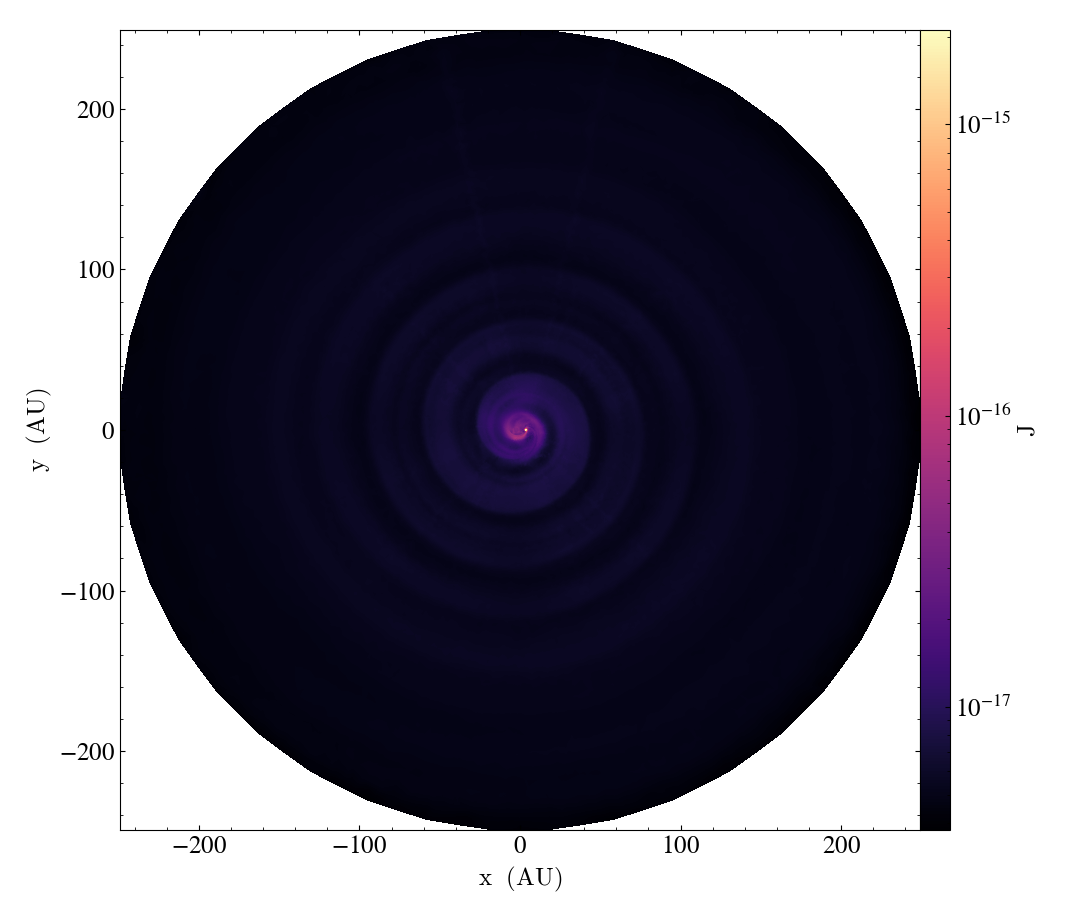

In [17]:
ds_NLTE_comoving = yt.load_unstructured_mesh(
    connectivity = delaunay_original.simplices.astype(np.int64),
    coordinates  = delaunay_original.points.astype(np.float64) * 100.0, # yt expects cm not m 
    node_data    = {('connect1', 'J'): NLTE_J_comoving[delaunay_original.simplices].astype(np.float64)}
)
sl = yt.SlicePlot (ds_NLTE_comoving, 'z', ('connect1','J'))
sl.set_cmap       (('connect1', 'J'), 'magma')
# sl.set_zlim(('connect1', 'J'), zmin=(5e-16, "1"), zmax=(3e-14, "1"))
sl.zoom           (1.1)

yt : [INFO     ] 2025-01-14 12:58:49,565 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-01-14 12:58:49,566 Parameters: domain_dimensions         = [2 2 2]
yt : [INFO     ] 2025-01-14 12:58:49,567 Parameters: domain_left_edge          = [-4.10031269e+15 -4.10031269e+15 -4.09575680e+15]
yt : [INFO     ] 2025-01-14 12:58:49,568 Parameters: domain_right_edge         = [4.10031269e+15 4.10031269e+15 4.09575680e+15]
yt : [INFO     ] 2025-01-14 12:58:49,569 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-01-14 12:58:50,143 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 12:58:50,144 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 12:58:50,148 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 12:58:50,149 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 12:58:50,152 Making a fixed resolution buffer of (('connect1', 'J'))


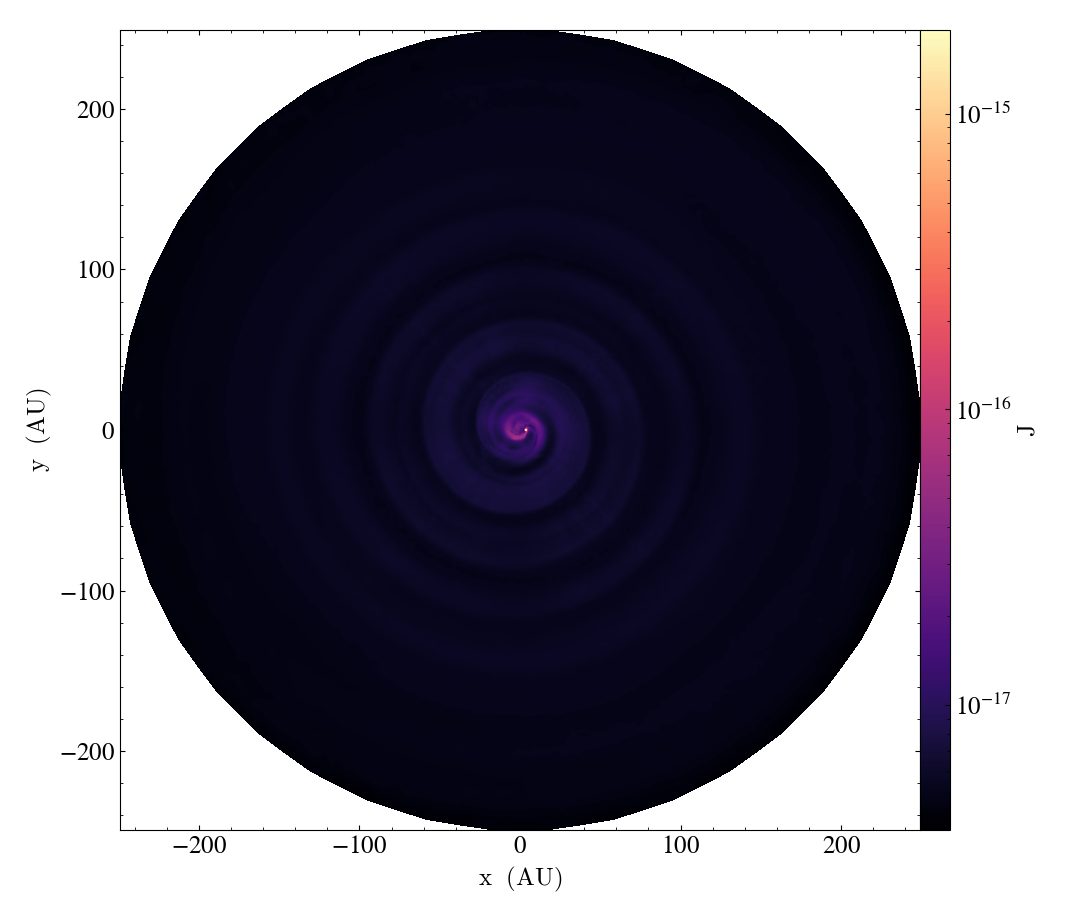

In [18]:
ds_NLTE_comapp = yt.load_unstructured_mesh(
    connectivity = delaunay_original.simplices.astype(np.int64),
    coordinates  = delaunay_original.points.astype(np.float64) * 100.0, # yt expects cm not m 
    node_data    = {('connect1', 'J'): NLTE_J_comapp[delaunay_original.simplices].astype(np.float64)}
)
sl = yt.SlicePlot (ds_NLTE_comapp, 'z', ('connect1','J'))
sl.set_cmap       (('connect1', 'J'), 'magma')
# sl.set_zlim(('connect1', 'J'), zmin=(5e-16, "1"), zmax=(3e-14, "1"))
sl.zoom           (1.1)

yt : [INFO     ] 2025-01-14 12:58:55,513 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 12:58:55,514 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 12:58:55,519 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 12:58:55,520 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 12:58:55,522 Making a fixed resolution buffer of (('connect1', 'J')) 800 by 800
yt : [INFO     ] 2025-01-14 12:59:00,400 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 12:59:00,401 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 12:59:00,405 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 12:59:00,406 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 12:59:00,408 Making a fixed resolution buffer of (('connect1', 'J')) 800 by 800
yt : [IN

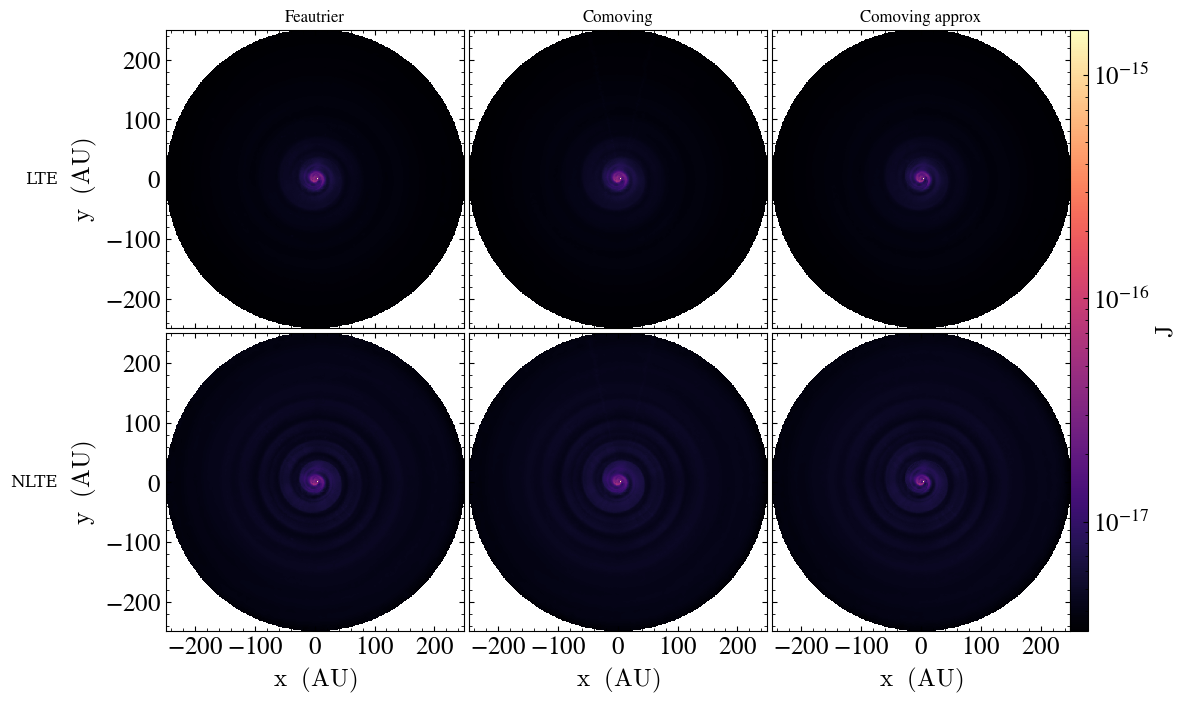

In [19]:
from mpl_toolkits.axes_grid1 import AxesGrid
fig = plt.figure()

grid = AxesGrid(fig, (0.075,0.075,0.85,0.85), nrows_ncols = (2, 3), axes_pad = 0.05, label_mode = "L", share_all = True, cbar_location="right", cbar_mode="single", cbar_size="3%", cbar_pad="0%")
data = [ds_feautrier_original, ds_comoving_original, ds_comapp_original, ds_NLTE_feautrier, ds_NLTE_comoving, ds_NLTE_comapp]
for i, dp in enumerate(data):
    sl = yt.SlicePlot (dp, 'z', ('connect1','J'))
    sl.set_cmap (('connect1', 'J'), 'magma')
    # sl.set_zlim(('connect1', 'J'), zmin=(1e-3, "1"), zmax=(3e-1, "1"))
    sl.zoom           (1.1)
    plot = sl.plots[('connect1','J')]
    plot.figure = fig
    plot.axes = grid[i].axes
    plot.cax = grid.cbar_axes[i]
    #forced redraw
    sl._setup_plots()

#now add the column titles
grid[0].set_title("Feautrier", size='large')
grid[1].set_title("Comoving", size='large')
grid[2].set_title("Comoving approx", size='large')
#padding
pad = 5#in points
#and set the row titles, keeping the y axis label
ax = grid[0].axes
ax.annotate('LTE', xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - pad, 0),
                xycoords=ax.yaxis.label, textcoords='offset points',
                size='large', ha='right', va='center')
ax = grid[3].axes
ax.annotate('NLTE', xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - pad, 0),
                xycoords=ax.yaxis.label, textcoords='offset points',
                size='large', ha='right', va='center')

# plt.tight_layout()
plt.savefig('all_intensities_combined.png', dpi=300, bbox_inches='tight')
plt.show()

Project reduced computed data onto original data

In [20]:
# # Find closest points
# corresp_points_gmsh = cKDTree(position_original).query(position_gmsh)[1]
# corresp_points_haar = cKDTree(position_original).query(position_haar)[1]
corresp_points_rec = np.array(cKDTree(position_original).query(position_rec)[1])
print(corresp_points_rec)

J_original = J_feautrier_original#1 it J on original grid
J_rec = J_feautrier#1 it J on reduced grid
print(J_original)
# #and do lazy projection onto reduced grids
prj_J_original_rec = J_original[corresp_points_rec]

#err, minor negative values may occur due to numerical issues, do check whether this is still the case


rel_diff_comoving = 1.0/2.0*np.abs(J_feautrier-J_comoving)/(J_feautrier+J_comoving)
rel_diff_comapp = 1.0/2.0*np.abs(J_feautrier-J_comapp)/(J_feautrier+J_comapp)
#rel_diff_shortchar = 1.0/2.0*np.abs(J_feautrier-J_shortchar)/(J_feautrier+J_shortchar)
rel_diff_rec = 1.0/2.0*np.abs(prj_J_original_rec-J_rec)/(prj_J_original_rec+J_rec)#diff versus projection? why did I even compute this?

#also for original grid
rel_diff_comoving_original = 1.0/2.0*np.abs(J_feautrier_original-J_comoving_original)/(J_feautrier_original+J_comoving_original)
rel_diff_comapp_original = 1.0/2.0*np.abs(J_feautrier_original-J_comapp_original)/(J_feautrier_original+J_comapp_original)

#and for NLTE
rel_diff_NLTE_comoving = 1.0/2.0*np.abs(NLTE_J_feautrier-NLTE_J_comoving)/(NLTE_J_feautrier+NLTE_J_comoving)
rel_diff_NLTE_comapp = 1.0/2.0*np.abs(NLTE_J_feautrier-NLTE_J_comapp)/(NLTE_J_feautrier+NLTE_J_comapp)

##also for uniform discretization
rel_diff_comoving_original_unif = 1.0/2.0*np.abs(J_feautrier_original_unif-J_comoving_original_unif)/(J_feautrier_original_unif+J_comoving_original_unif)
rel_diff_comapp_original_unif = 1.0/2.0*np.abs(J_feautrier_original_unif-J_comapp_original_unif)/(J_feautrier_original_unif+J_comapp_original_unif)

#and for NLTE
rel_diff_NLTE_comoving_unif = 1.0/2.0*np.abs(NLTE_J_feautrier_unif-NLTE_J_comoving_unif)/(NLTE_J_feautrier_unif+NLTE_J_comoving_unif)
rel_diff_NLTE_comapp_unif = 1.0/2.0*np.abs(NLTE_J_feautrier_unif-NLTE_J_comapp_unif)/(NLTE_J_feautrier_unif+NLTE_J_comapp_unif)


[    0     1     2 ... 75381 46895 67743]
[3.17642808e-18 3.17425848e-18 3.17400553e-18 ... 3.76457103e-17
 3.73138721e-17 3.62561747e-17]


In [21]:
# print(prj_J_original_gmsh.shape)
# print(prj_J_original_haar.shape)
# print(prj_J_original_rec.shape)
print(J_original.shape)
print(NLTE_J_comapp.shape)
print(np.min(rel_diff_NLTE_comoving))
print(np.min(NLTE_J_comoving))
print(np.min(J_comoving_original))
print(np.min(J_comapp_original))

(885501,)
(885501,)
7.98897125198315e-11
3.174100455707639e-18
3.1736187118793116e-18
3.173698126922343e-18


Plot the relative differences (I expect the largest differences to reside in the middle)

yt : [INFO     ] 2025-01-14 12:59:33,076 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-01-14 12:59:33,077 Parameters: domain_dimensions         = [2 2 2]
yt : [INFO     ] 2025-01-14 12:59:33,078 Parameters: domain_left_edge          = [-4.10031269e+15 -4.10031269e+15 -4.09575680e+15]
yt : [INFO     ] 2025-01-14 12:59:33,079 Parameters: domain_right_edge         = [4.10031269e+15 4.10031269e+15 4.09575680e+15]
yt : [INFO     ] 2025-01-14 12:59:33,080 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-01-14 12:59:33,241 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 12:59:33,242 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 12:59:33,246 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 12:59:33,247 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 12:59:33,250 Making a fixed resolution buffer of (('connect1', 'J_re


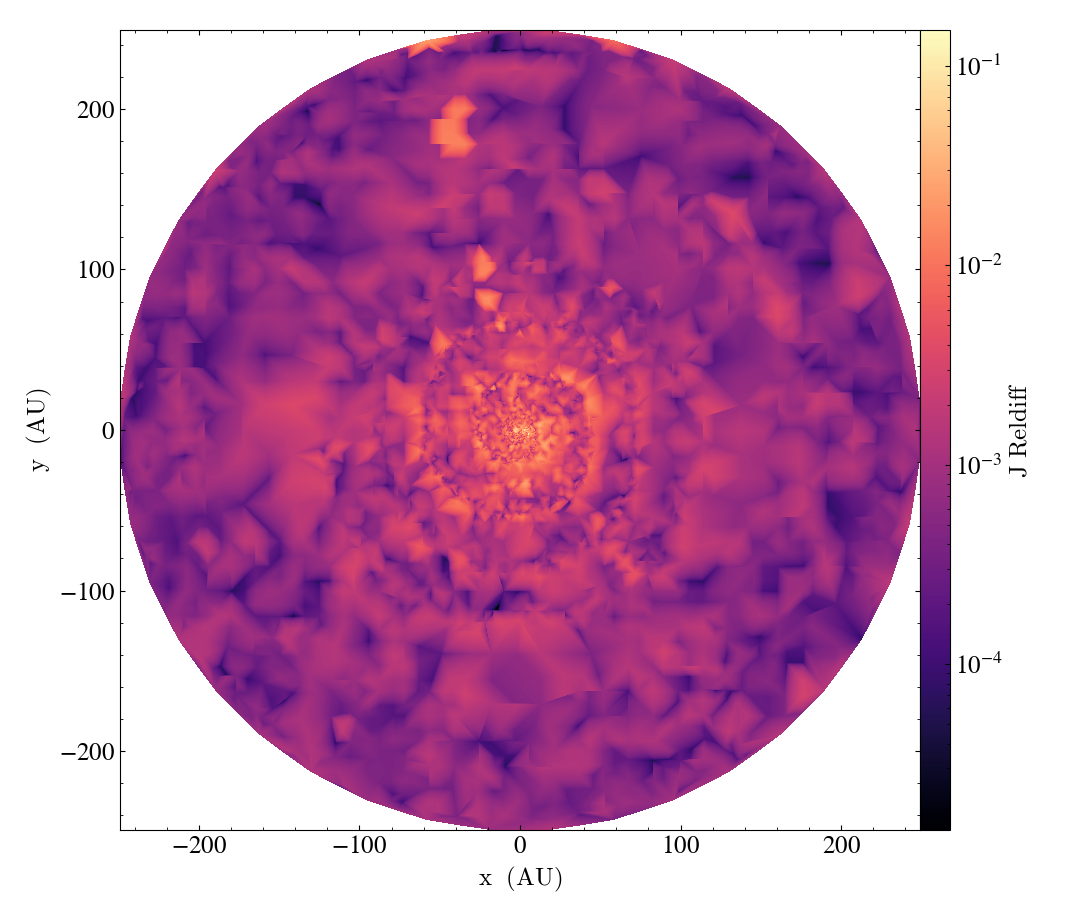

In [22]:
#comoving
diff_comoving = yt.load_unstructured_mesh(
    connectivity = delaunay_rec.simplices.astype(np.int64),
    coordinates  = delaunay_rec.points.astype(np.float64) * 100.0, # yt expects cm not m 
    node_data    = {('connect1', 'J_reldiff'): rel_diff_comoving[delaunay_rec.simplices].astype(np.float64)}
)
sl = yt.SlicePlot (diff_comoving, 'z', ('connect1','J_reldiff'))
sl.set_cmap       (('connect1', 'J_reldiff'), 'magma')
# sl.set_zlim(('connect1', 'J_reldiff'), zmin=(1e-6, "1"), zmax=(3e-0, "1"))
sl.zoom           (1.1)

yt : [INFO     ] 2025-01-14 12:59:35,423 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-01-14 12:59:35,424 Parameters: domain_dimensions         = [2 2 2]
yt : [INFO     ] 2025-01-14 12:59:35,425 Parameters: domain_left_edge          = [-4.10031269e+15 -4.10031269e+15 -4.09575680e+15]
yt : [INFO     ] 2025-01-14 12:59:35,426 Parameters: domain_right_edge         = [4.10031269e+15 4.10031269e+15 4.09575680e+15]
yt : [INFO     ] 2025-01-14 12:59:35,427 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-01-14 12:59:35,584 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 12:59:35,585 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 12:59:35,589 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 12:59:35,590 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 12:59:35,593 Making a fixed resolution buffer of (('connect1', 'J_re


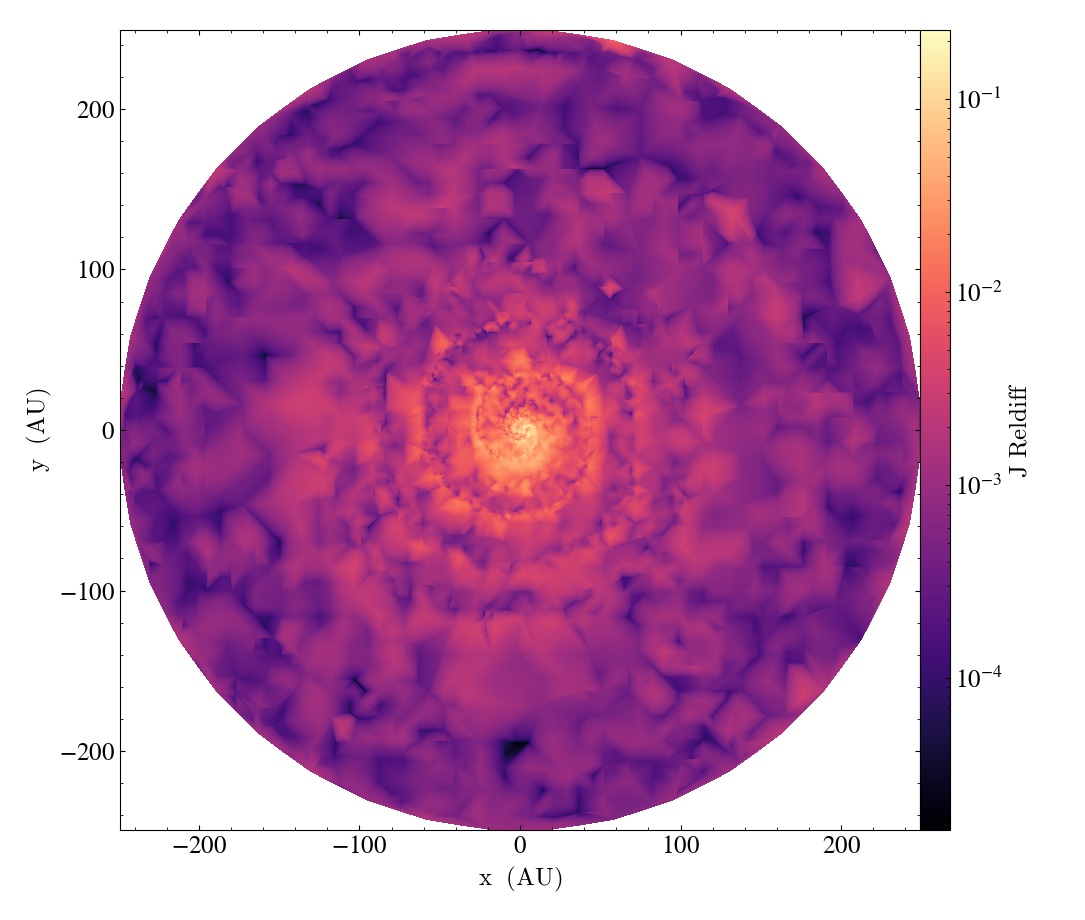

In [23]:
#comoving approx
diff_comapp = yt.load_unstructured_mesh(
    connectivity = delaunay_rec.simplices.astype(np.int64),
    coordinates  = delaunay_rec.points.astype(np.float64) * 100.0, # yt expects cm not m 
    node_data    = {('connect1', 'J_reldiff'): rel_diff_comapp[delaunay_rec.simplices].astype(np.float64)}
)
sl = yt.SlicePlot (diff_comapp, 'z', ('connect1','J_reldiff'))
sl.set_cmap       (('connect1', 'J_reldiff'), 'magma')
# sl.set_zlim(('connect1', 'J_reldiff'), zmin=(1e-6, "1"), zmax=(3e-1, "1"))
sl.zoom           (1.1)

In [24]:
# #shortchar
# diff_shortchar = yt.load_unstructured_mesh(
#     connectivity = delaunay_rec.simplices.astype(np.int64),
#     coordinates  = delaunay_rec.points.astype(np.float64) * 100.0, # yt expects cm not m 
#     node_data    = {('connect1', 'J_reldiff'): rel_diff_shortchar[delaunay_rec.simplices].astype(np.float64)}
# )
# sl = yt.SlicePlot (diff_shortchar, 'z', ('connect1','J_reldiff'))
# sl.set_cmap       (('connect1', 'J_reldiff'), 'magma')
# sl.set_zlim(('connect1', 'J_reldiff'), zmin=(1e-6, "1"), zmax=(3e-1, "1"))
# sl.zoom           (1.1)

yt : [INFO     ] 2025-01-14 12:59:38,396 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-01-14 12:59:38,397 Parameters: domain_dimensions         = [2 2 2]
yt : [INFO     ] 2025-01-14 12:59:38,401 Parameters: domain_left_edge          = [-4.10031269e+15 -4.10031269e+15 -4.09575680e+15]
yt : [INFO     ] 2025-01-14 12:59:38,402 Parameters: domain_right_edge         = [4.10031269e+15 4.10031269e+15 4.09575680e+15]
yt : [INFO     ] 2025-01-14 12:59:38,403 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-01-14 12:59:39,308 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 12:59:39,310 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 12:59:39,314 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 12:59:39,315 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 12:59:39,317 Making a fixed resolution buffer of (('connect1', 'J_re


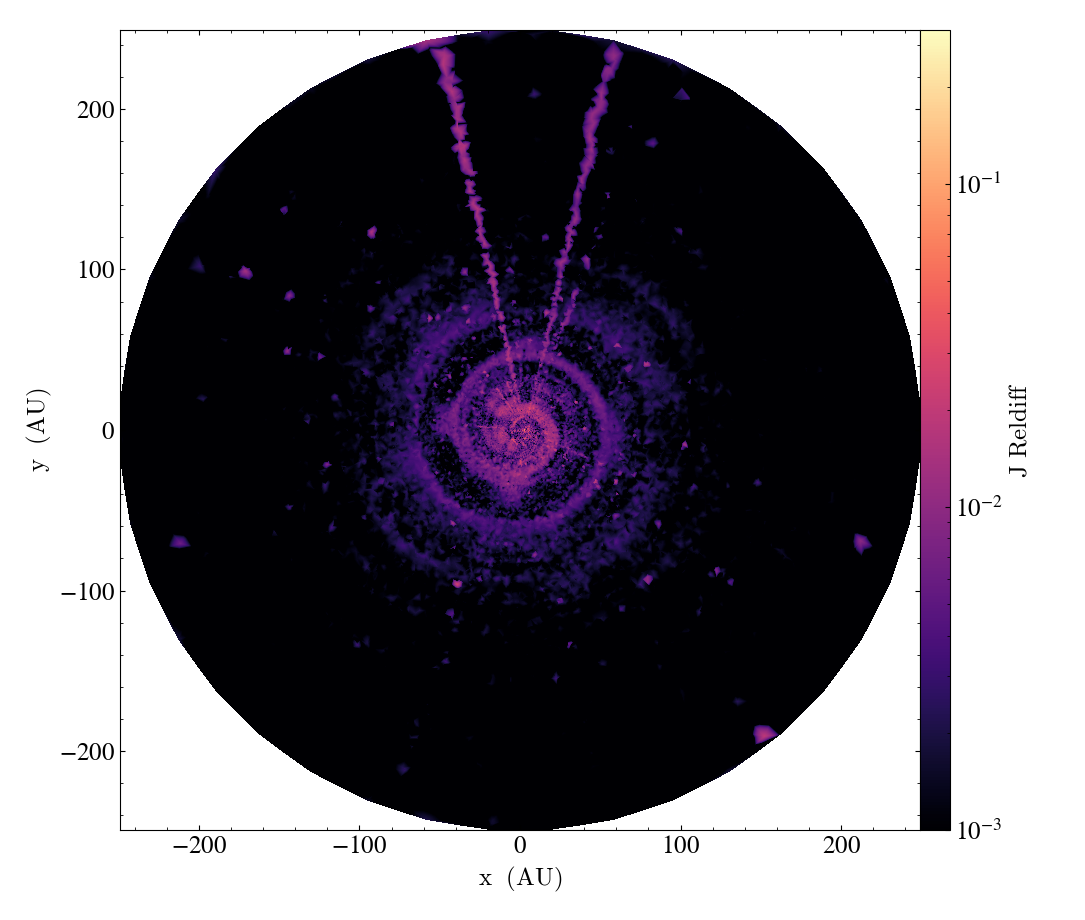

In [25]:
#comoving on original grid
diff_comoving_original = yt.load_unstructured_mesh(
    connectivity = delaunay_original.simplices.astype(np.int64),
    coordinates  = delaunay_original.points.astype(np.float64) * 100.0, # yt expects cm not m 
    node_data    = {('connect1', 'J_reldiff'): rel_diff_comoving_original[delaunay_original.simplices].astype(np.float64)}
)
sl = yt.SlicePlot (diff_comoving_original, 'z', ('connect1','J_reldiff'))
sl.set_cmap       (('connect1', 'J_reldiff'), 'magma')
sl.set_zlim(('connect1', 'J_reldiff'), zmin=(1e-3, "1"), zmax=(3e-1, "1"))
sl.zoom           (1.1)
# sl.save('diff_comoving_original.png')

yt : [INFO     ] 2025-01-14 12:59:44,481 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-01-14 12:59:44,482 Parameters: domain_dimensions         = [2 2 2]
yt : [INFO     ] 2025-01-14 12:59:44,483 Parameters: domain_left_edge          = [-4.10031269e+15 -4.10031269e+15 -4.09575680e+15]
yt : [INFO     ] 2025-01-14 12:59:44,484 Parameters: domain_right_edge         = [4.10031269e+15 4.10031269e+15 4.09575680e+15]
yt : [INFO     ] 2025-01-14 12:59:44,485 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-01-14 12:59:45,055 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 12:59:45,057 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 12:59:45,060 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 12:59:45,061 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 12:59:45,064 Making a fixed resolution buffer of (('connect1', 'J_re


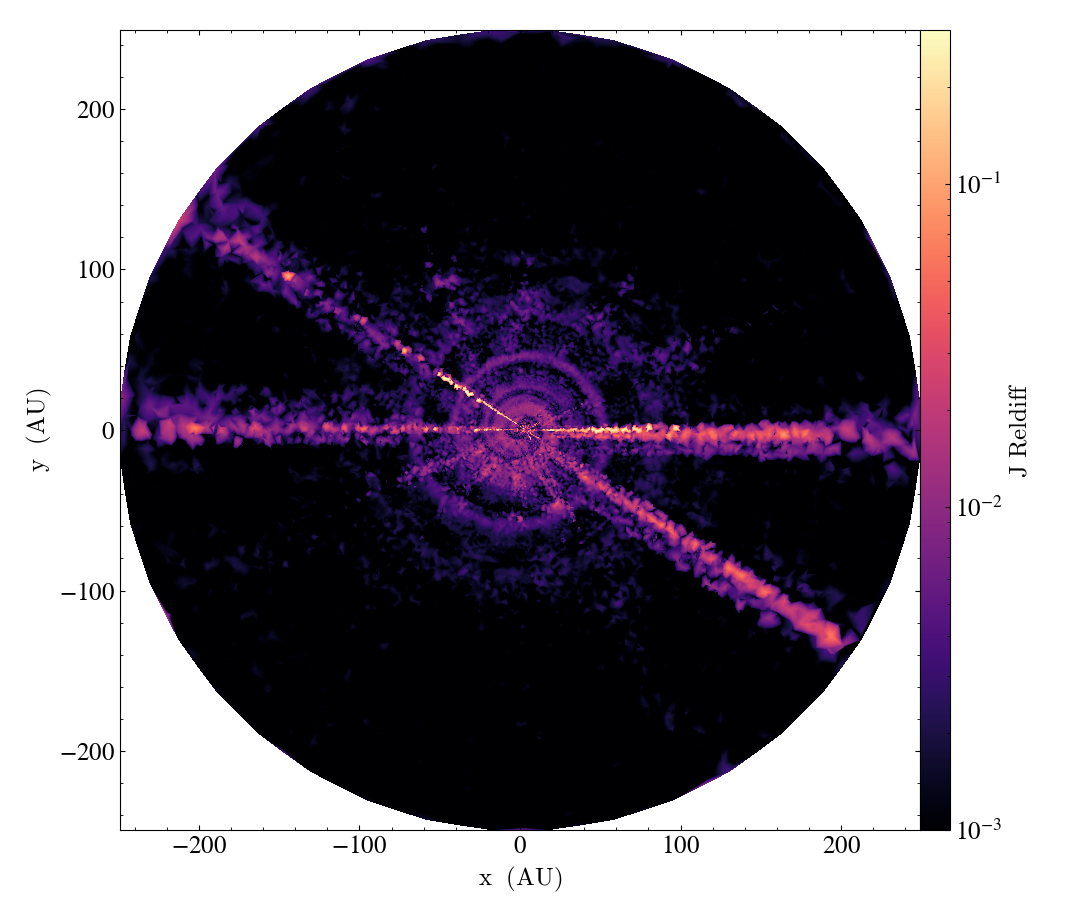

In [26]:
#comoving on original grid (uniform angular discretization)
diff_comoving_original_unif = yt.load_unstructured_mesh(
    connectivity = delaunay_original.simplices.astype(np.int64),
    coordinates  = delaunay_original.points.astype(np.float64) * 100.0, # yt expects cm not m 
    node_data    = {('connect1', 'J_reldiff'): rel_diff_comoving_original_unif[delaunay_original.simplices].astype(np.float64)}
)
sl = yt.SlicePlot (diff_comoving_original_unif, 'z', ('connect1','J_reldiff'))
sl.set_cmap       (('connect1', 'J_reldiff'), 'magma')
sl.set_zlim(('connect1', 'J_reldiff'), zmin=(1e-3, "1"), zmax=(3e-1, "1"))
sl.zoom           (1.1)
# sl.save('diff_comoving_original.png')

yt : [INFO     ] 2025-01-14 12:59:50,204 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-01-14 12:59:50,205 Parameters: domain_dimensions         = [2 2 2]
yt : [INFO     ] 2025-01-14 12:59:50,206 Parameters: domain_left_edge          = [-4.10031269e+15 -4.10031269e+15 -4.09575680e+15]
yt : [INFO     ] 2025-01-14 12:59:50,207 Parameters: domain_right_edge         = [4.10031269e+15 4.10031269e+15 4.09575680e+15]
yt : [INFO     ] 2025-01-14 12:59:50,208 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-01-14 12:59:50,775 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 12:59:50,776 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 12:59:50,780 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 12:59:50,781 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 12:59:50,784 Making a fixed resolution buffer of (('connect1', 'J_re


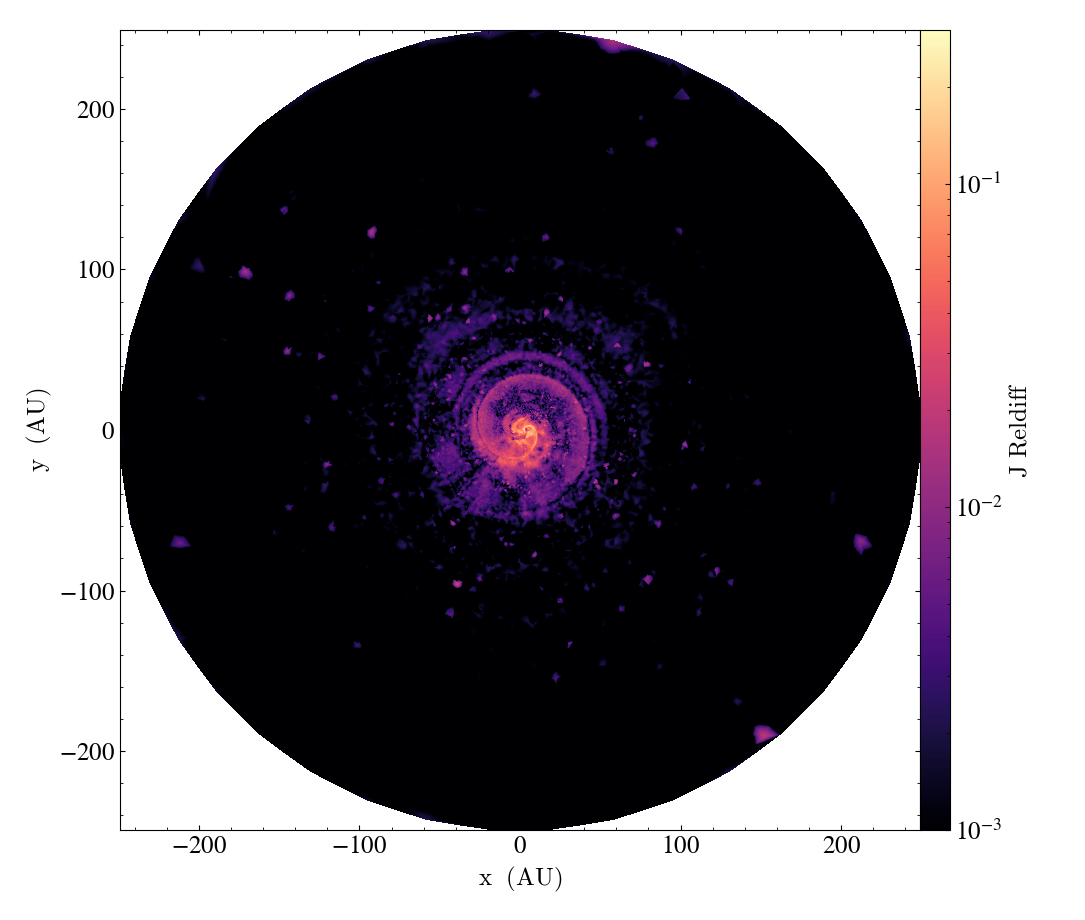

In [27]:
#comoving approx on original grid
diff_comapp_original = yt.load_unstructured_mesh(
    connectivity = delaunay_original.simplices.astype(np.int64),
    coordinates  = delaunay_original.points.astype(np.float64) * 100.0, # yt expects cm not m 
    node_data    = {('connect1', 'J_reldiff'): rel_diff_comapp_original[delaunay_original.simplices].astype(np.float64)}
)
sl = yt.SlicePlot (diff_comapp_original, 'z', ('connect1','J_reldiff'))
sl.set_cmap       (('connect1', 'J_reldiff'), 'magma')
sl.set_zlim(('connect1', 'J_reldiff'), zmin=(1e-3, "1"), zmax=(3e-1, "1"))
sl.zoom           (1.1)
# sl.save('diff_comapp_original.png')

yt : [INFO     ] 2025-01-14 12:59:55,818 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-01-14 12:59:55,819 Parameters: domain_dimensions         = [2 2 2]
yt : [INFO     ] 2025-01-14 12:59:55,821 Parameters: domain_left_edge          = [-4.10031269e+15 -4.10031269e+15 -4.09575680e+15]
yt : [INFO     ] 2025-01-14 12:59:55,822 Parameters: domain_right_edge         = [4.10031269e+15 4.10031269e+15 4.09575680e+15]
yt : [INFO     ] 2025-01-14 12:59:55,823 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-01-14 12:59:56,396 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 12:59:56,398 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 12:59:56,402 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 12:59:56,403 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 12:59:56,406 Making a fixed resolution buffer of (('connect1', 'J_re


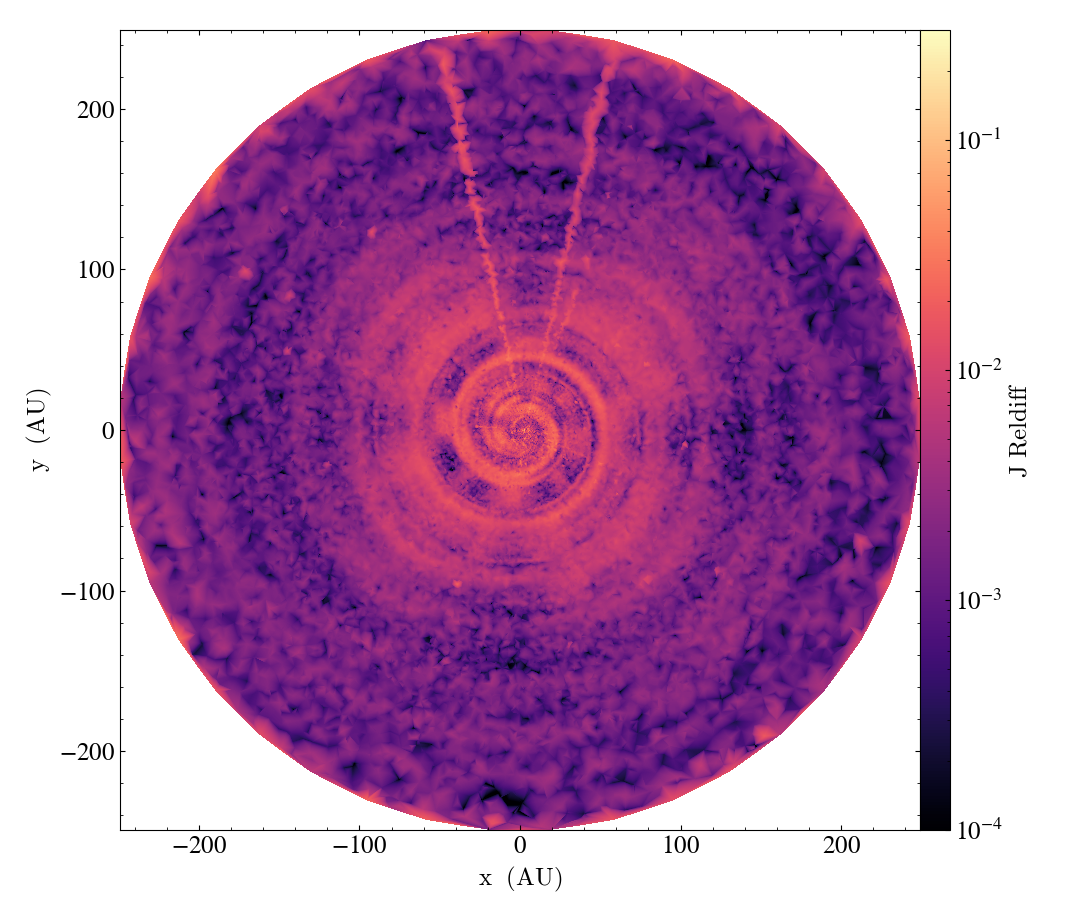

In [28]:
#NLTE diffs comoving vs feautrier
diff_NLTE_comoving = yt.load_unstructured_mesh(
    connectivity = delaunay_original.simplices.astype(np.int64),
    coordinates  = delaunay_original.points.astype(np.float64) * 100.0, # yt expects cm not m 
    node_data    = {('connect1', 'J_reldiff'): rel_diff_NLTE_comoving[delaunay_original.simplices].astype(np.float64)}
)
sl = yt.SlicePlot (diff_NLTE_comoving, 'z', ('connect1','J_reldiff'))
sl.set_cmap       (('connect1', 'J_reldiff'), 'magma')
sl.set_zlim(('connect1', 'J_reldiff'), zmin=(1e-4, "1"), zmax=(3e-1, "1"))
sl.zoom           (1.1)
# sl.save('diff_NLTE_comoving.png')

yt : [INFO     ] 2025-01-14 13:00:01,728 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-01-14 13:00:01,730 Parameters: domain_dimensions         = [2 2 2]
yt : [INFO     ] 2025-01-14 13:00:01,731 Parameters: domain_left_edge          = [-4.10031269e+15 -4.10031269e+15 -4.09575680e+15]
yt : [INFO     ] 2025-01-14 13:00:01,732 Parameters: domain_right_edge         = [4.10031269e+15 4.10031269e+15 4.09575680e+15]
yt : [INFO     ] 2025-01-14 13:00:01,733 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-01-14 13:00:02,308 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 13:00:02,309 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 13:00:02,314 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 13:00:02,314 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 13:00:02,319 Making a fixed resolution buffer of (('connect1', 'J_re


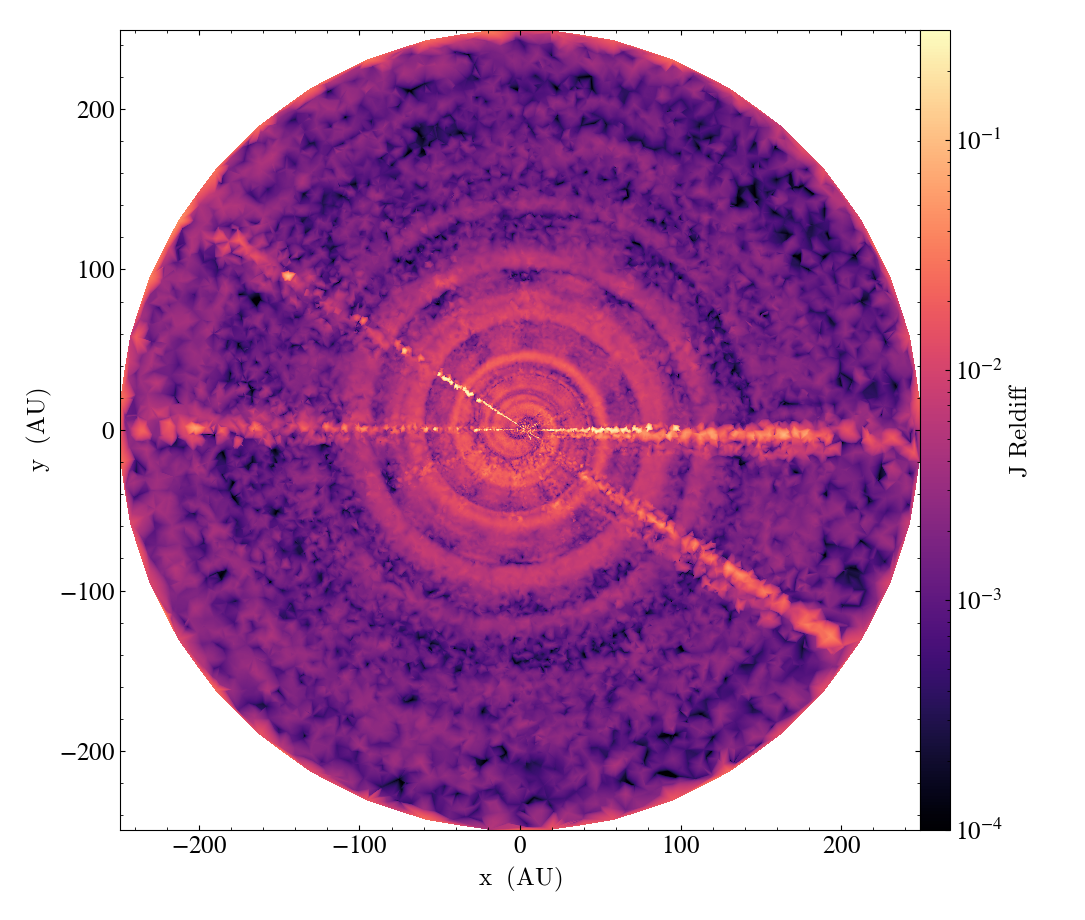

In [29]:
#NLTE diffs comoving vs feautrier (uniform angular discretization)
diff_NLTE_comoving_unif = yt.load_unstructured_mesh(
    connectivity = delaunay_original.simplices.astype(np.int64),
    coordinates  = delaunay_original.points.astype(np.float64) * 100.0, # yt expects cm not m 
    node_data    = {('connect1', 'J_reldiff'): rel_diff_NLTE_comoving_unif[delaunay_original.simplices].astype(np.float64)}
)
sl = yt.SlicePlot (diff_NLTE_comoving_unif, 'z', ('connect1','J_reldiff'))
sl.set_cmap       (('connect1', 'J_reldiff'), 'magma')
sl.set_zlim(('connect1', 'J_reldiff'), zmin=(1e-4, "1"), zmax=(3e-1, "1"))
sl.zoom           (1.1)
# sl.save('diff_NLTE_comoving.png')

yt : [INFO     ] 2025-01-14 13:00:08,090 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-01-14 13:00:08,091 Parameters: domain_dimensions         = [2 2 2]
yt : [INFO     ] 2025-01-14 13:00:08,092 Parameters: domain_left_edge          = [-4.10031269e+15 -4.10031269e+15 -4.09575680e+15]
yt : [INFO     ] 2025-01-14 13:00:08,093 Parameters: domain_right_edge         = [4.10031269e+15 4.10031269e+15 4.09575680e+15]
yt : [INFO     ] 2025-01-14 13:00:08,094 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-01-14 13:00:08,711 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 13:00:08,712 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 13:00:08,716 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 13:00:08,717 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 13:00:08,720 Making a fixed resolution buffer of (('connect1', 'J_re


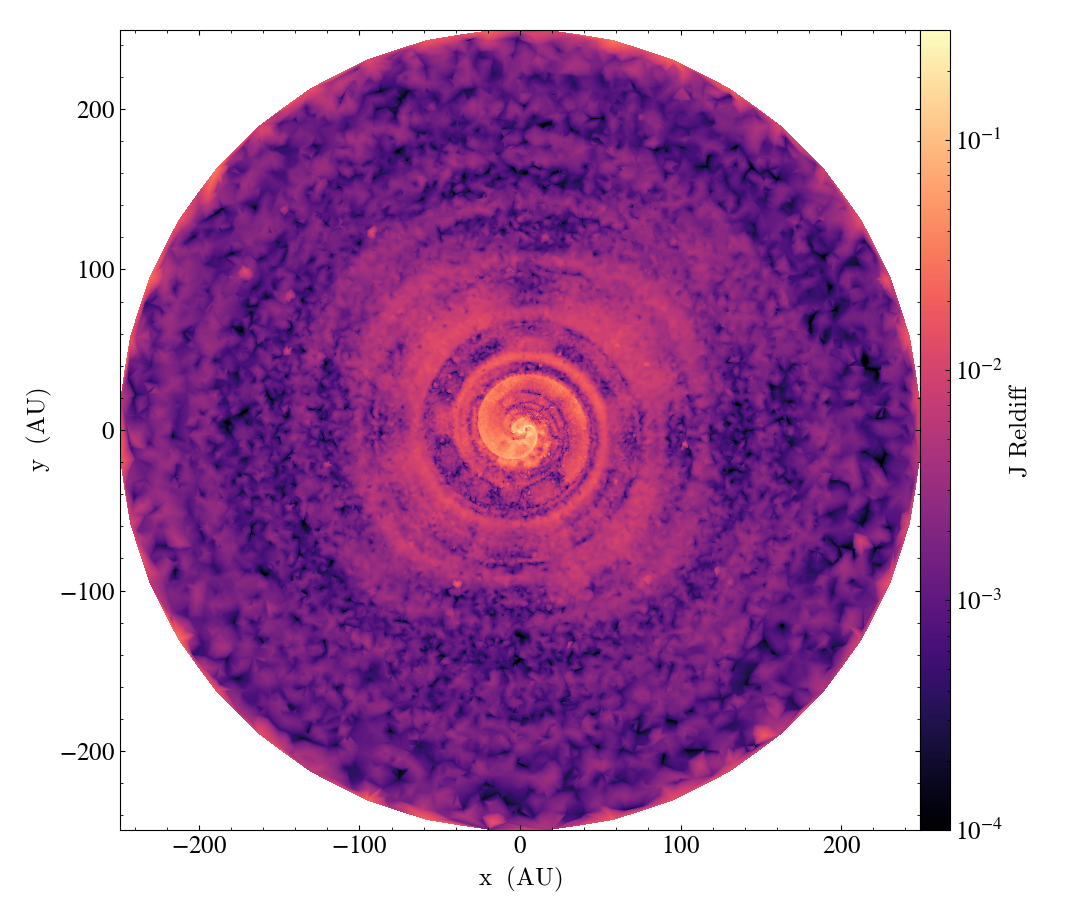

In [30]:
#NLTE diffs comoving approx vs feautrier
diff_NLTE_comapp = yt.load_unstructured_mesh(
    connectivity = delaunay_original.simplices.astype(np.int64),
    coordinates  = delaunay_original.points.astype(np.float64) * 100.0, # yt expects cm not m 
    node_data    = {('connect1', 'J_reldiff'): rel_diff_NLTE_comapp[delaunay_original.simplices].astype(np.float64)}
)
sl = yt.SlicePlot (diff_NLTE_comapp, 'z', ('connect1','J_reldiff'))
sl.set_cmap       (('connect1', 'J_reldiff'), 'magma')
sl.set_zlim(('connect1', 'J_reldiff'), zmin=(1e-4, "1"), zmax=(3e-1, "1"))
sl.zoom           (1.1)
# sl.save('diff_NLTE_comapp.png')

Now plotting all these results together in a single plot

yt : [INFO     ] 2025-01-14 13:00:14,367 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 13:00:14,369 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 13:00:14,373 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 13:00:14,373 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 13:00:14,375 Making a fixed resolution buffer of (('connect1', 'J_reldiff')) 800 by 800
yt : [INFO     ] 2025-01-14 13:00:18,982 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 13:00:18,984 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 13:00:18,988 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 13:00:18,989 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 13:00:18,991 Making a fixed resolution buffer of (('connect1', 'J_reldiff')) 800

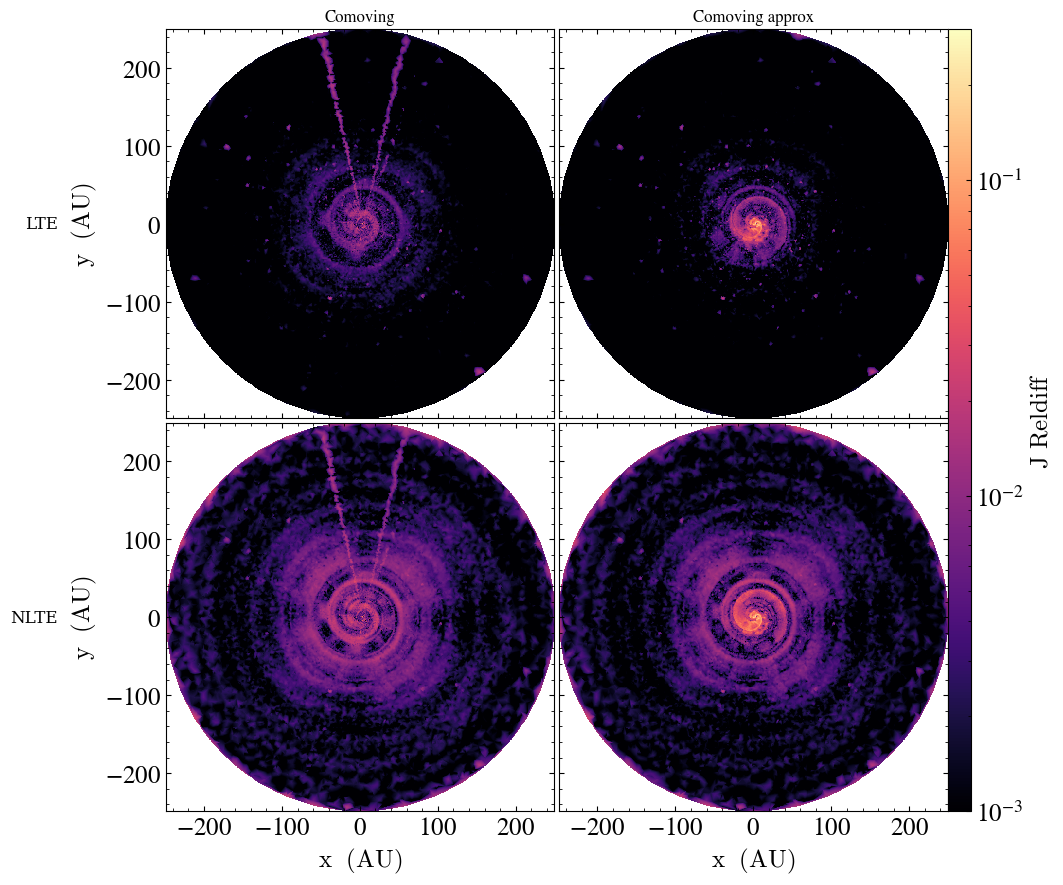

In [31]:
from mpl_toolkits.axes_grid1 import AxesGrid
fig = plt.figure()

grid = AxesGrid(fig, (0.075,0.075,0.85,0.85), nrows_ncols = (2, 2), axes_pad = 0.05, label_mode = "L", share_all = True, cbar_location="right", cbar_mode="single", cbar_size="3%", cbar_pad="0%")
data = [diff_comoving_original, diff_comapp_original, diff_NLTE_comoving, diff_NLTE_comapp]
for i, dp in enumerate(data):
    sl = yt.SlicePlot (dp, 'z', ('connect1','J_reldiff'))
    sl.set_cmap (('connect1', 'J_reldiff'), 'magma')
    sl.set_zlim(('connect1', 'J_reldiff'), zmin=(1e-3, "1"), zmax=(3e-1, "1"))
    sl.zoom           (1.1)
    plot = sl.plots[('connect1','J_reldiff')]
    plot.figure = fig
    plot.axes = grid[i].axes
    plot.cax = grid.cbar_axes[i]
    #forced redraw
    sl._setup_plots()

#now add the column titles
grid[0].set_title("Comoving", size='large')
grid[1].set_title("Comoving approx", size='large')
#padding
pad = 5#in points
#and set the row titles, keeping the y axis label
ax = grid[0].axes
ax.annotate('LTE', xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - pad, 0),
                xycoords=ax.yaxis.label, textcoords='offset points',
                size='large', ha='right', va='center')
ax = grid[2].axes
ax.annotate('NLTE', xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - pad, 0),
                xycoords=ax.yaxis.label, textcoords='offset points',
                size='large', ha='right', va='center')

# plt.tight_layout()
plt.savefig('reldiff_comoving_combined.png', dpi=300, bbox_inches='tight')
plt.show()


yt : [INFO     ] 2025-01-14 13:00:40,916 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 13:00:40,917 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 13:00:40,922 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 13:00:40,924 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 13:00:40,926 Making a fixed resolution buffer of (('connect1', 'J_reldiff')) 800 by 800
yt : [INFO     ] 2025-01-14 13:00:45,927 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 13:00:45,928 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 13:00:45,933 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 13:00:45,933 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 13:00:45,935 Making a fixed resolution buffer of (('connect1', 'J_reldiff')) 800

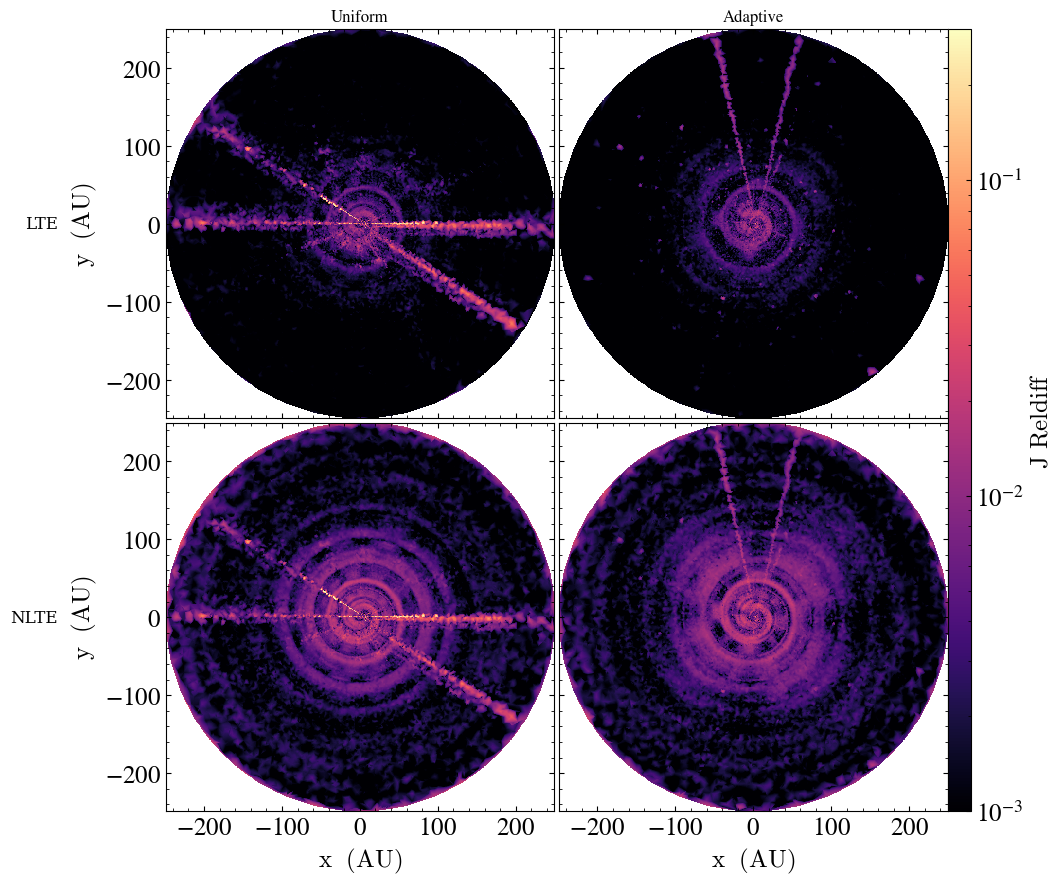

In [32]:
from mpl_toolkits.axes_grid1 import AxesGrid
fig = plt.figure()

grid = AxesGrid(fig, (0.075,0.075,0.85,0.85), nrows_ncols = (2, 2), axes_pad = 0.05, label_mode = "L", share_all = True, cbar_location="right", cbar_mode="single", cbar_size="3%", cbar_pad="0%")
data = [diff_comoving_original_unif,diff_comoving_original, diff_NLTE_comoving_unif, diff_NLTE_comoving]
for i, dp in enumerate(data):
    sl = yt.SlicePlot (dp, 'z', ('connect1','J_reldiff'))
    sl.set_cmap (('connect1', 'J_reldiff'), 'magma')
    sl.set_zlim(('connect1', 'J_reldiff'), zmin=(1e-3, "1"), zmax=(3e-1, "1"))
    sl.zoom           (1.1)
    plot = sl.plots[('connect1','J_reldiff')]
    plot.figure = fig
    plot.axes = grid[i].axes
    plot.cax = grid.cbar_axes[i]
    #forced redraw
    sl._setup_plots()

#now add the column titles
grid[0].set_title("Uniform", size='large')
grid[1].set_title("Adaptive", size='large')
#padding
pad = 5#in points
#and set the row titles, keeping the y axis label
ax = grid[0].axes
ax.annotate('LTE', xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - pad, 0),
                xycoords=ax.yaxis.label, textcoords='offset points',
                size='large', ha='right', va='center')
ax = grid[2].axes
ax.annotate('NLTE', xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - pad, 0),
                xycoords=ax.yaxis.label, textcoords='offset points',
                size='large', ha='right', va='center')

# plt.tight_layout()
plt.savefig('reldiff_comoving_uniformvsadaptive.png', dpi=300, bbox_inches='tight')
plt.show()


In [33]:
# #bugged multiline diffs comoving vs feautrier
# diff_l0_comoving = yt.load_unstructured_mesh(
#     connectivity = delaunay_rec.simplices.astype(np.int64),
#     coordinates  = delaunay_rec.points.astype(np.float64) * 100.0, # yt expects cm not m 
#     node_data    = {('connect1', 'J_reldiff'): rel_diff_comoving_l0[delaunay_rec.simplices].astype(np.float64)}
# )
# sl = yt.SlicePlot (diff_l0_comoving, 'z', ('connect1','J_reldiff'))
# sl.set_cmap       (('connect1', 'J_reldiff'), 'magma')
# sl.set_zlim(('connect1', 'J_reldiff'), zmin=(1e-6, "1"), zmax=(3e-1, "1"))
# sl.zoom           (1.1)

In [34]:
# #multiline diffs comoving vs feautrier
# #the relative diffs sem larger, as the line is quite a bit weaker
# diff_l1_comoving = yt.load_unstructured_mesh(
#     connectivity = delaunay_rec.simplices.astype(np.int64),
#     coordinates  = delaunay_rec.points.astype(np.float64) * 100.0, # yt expects cm not m 
#     node_data    = {('connect1', 'J_reldiff'): rel_diff_comoving_l1[delaunay_rec.simplices].astype(np.float64)}
# )
# sl = yt.SlicePlot (diff_l1_comoving, 'z', ('connect1','J_reldiff'))
# sl.set_cmap       (('connect1', 'J_reldiff'), 'magma')
# sl.set_zlim(('connect1', 'J_reldiff'), zmin=(1e-6, "1"), zmax=(3e-1, "1"))
# sl.zoom           (1.1)

#haar
diff_haar = yt.load_unstructured_mesh(
    connectivity = delaunay_haar.simplices.astype(np.int64),
    coordinates  = delaunay_haar.points.astype(np.float64) * 100.0, # yt expects cm not m 
    node_data    = {('connect1', 'J_reldiff'): rel_diff_haar[delaunay_haar.simplices].astype(np.float64)}
)
sl = yt.SlicePlot (diff_haar, 'z', ('connect1','J_reldiff'))
sl.set_cmap       (('connect1', 'J_reldiff'), 'magma')
sl.set_zlim(('connect1', 'J_reldiff'), zmin=(1e-6, "1"), zmax=(3e-1, "1"))
sl.zoom           (1.1)

Because a figure might not tell us everything, we also plot a CDF of the relative errors.
In this, we notice that some differences exist in the slopes; gmsh might do better for the smaller scale structures, while ... err, this might be incorrect; we might just need to compare on the correct grid (original grid).

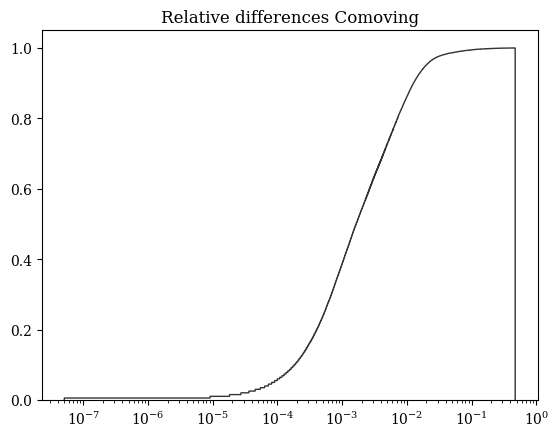

In [35]:
plt.figure()
plt.hist(rel_diff_comoving, cumulative=True, label='Comoving', density=True,
         bins=len(rel_diff_comoving), histtype='step', alpha=0.8, color='k')
plt.xscale('log')
# plt.xlim(1e-6,3e-1)
plt.title("Relative differences Comoving")
plt.show()

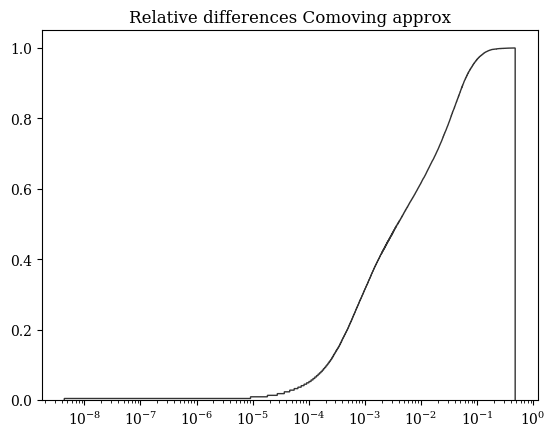

In [36]:
plt.figure()
plt.hist(rel_diff_comapp, cumulative=True, label='Comoving approx', density=True,
         bins = len(rel_diff_comapp), histtype='step', alpha=0.8, color='k')
plt.xscale('log')
# plt.xlim(1e-6,3e-1)
plt.title("Relative differences Comoving approx")
plt.show()

In [37]:
#plt.figure()
#plt.hist(rel_diff_shortchar, cumulative=True, label='Shortchar', density=True,
#         bins = len(rel_diff_shortchar), histtype='step', alpha=0.8, color='k')
#plt.xscale('log')
#plt.xlim(1e-6,3e-1)
#plt.title("Relative differences Shortchar")
#plt.show()

Err, we might just plot them together

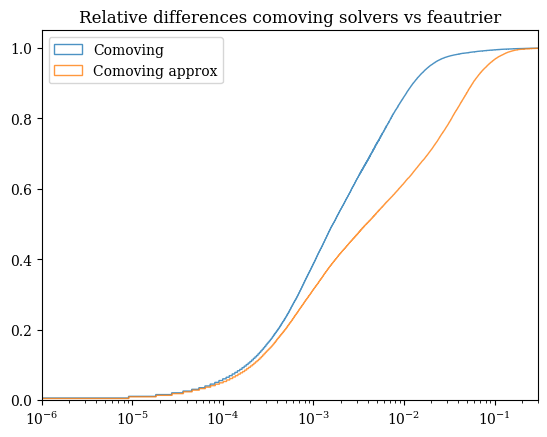

In [38]:
plt.figure()
plt.hist(rel_diff_comoving, cumulative=True, label='Comoving', density=True,
         bins=len(rel_diff_comoving), histtype='step', alpha=0.8)
plt.hist(rel_diff_comapp, cumulative=True, label='Comoving approx', density=True,
         bins = len(rel_diff_comapp), histtype='step', alpha=0.8)
#plt.hist(rel_diff_shortchar, cumulative=True, label='Shortchar', density=True,
#         bins = len(rel_diff_shortchar), histtype='step', alpha=0.8)
plt.xscale('log')
plt.xlim(1e-6,3e-1)
plt.legend(loc = "upper left")
plt.title("Relative differences comoving solvers vs feautrier")
plt.show()

Also create the same plot for the original grid. (I do not see major differences, just more points at irrelevant locations being computed accurately)

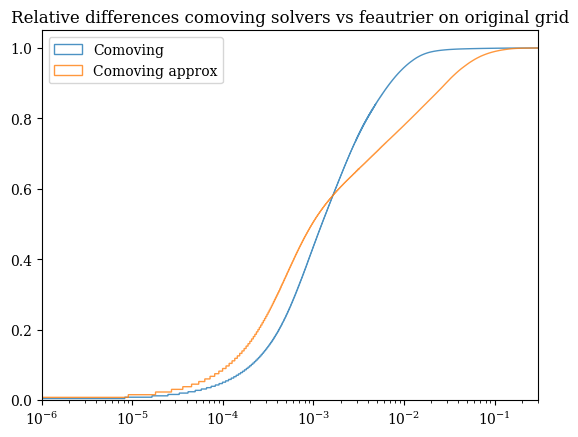

In [39]:
plt.figure()
plt.hist(rel_diff_comoving_original, cumulative=True, label='Comoving', density=True,
         bins=len(rel_diff_comoving), histtype='step', alpha=0.8)
plt.hist(rel_diff_comapp_original, cumulative=True, label='Comoving approx', density=True,
         bins = len(rel_diff_comapp), histtype='step', alpha=0.8)
plt.xscale('log')
plt.xlim(1e-6,3e-1)
plt.legend(loc = "upper left")
plt.title("Relative differences comoving solvers vs feautrier on original grid")
plt.savefig("wind_model_original_reldiffs_comoving.jpg")
plt.show()

And for the NLTE J on the reduced mesh.

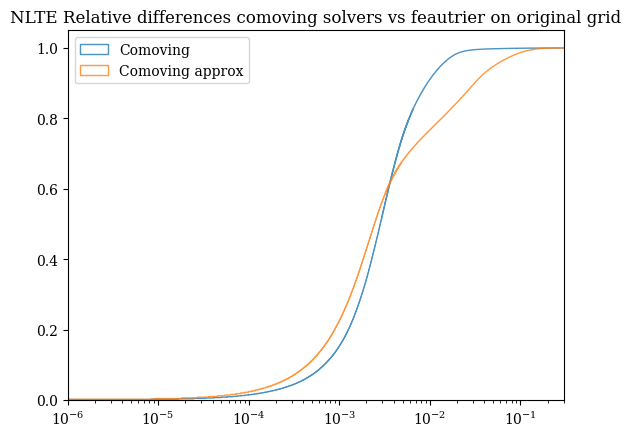

In [40]:
plt.figure()
plt.hist(rel_diff_NLTE_comoving, cumulative=True, label='Comoving', density=True,
         bins=len(rel_diff_comoving), histtype='step', alpha=0.8)
plt.hist(rel_diff_NLTE_comapp, cumulative=True, label='Comoving approx', density=True,
         bins = len(rel_diff_comapp), histtype='step', alpha=0.8)
plt.xscale('log')
plt.xlim(1e-6,3e-1)
plt.legend(loc = "upper left")
plt.title("NLTE Relative differences comoving solvers vs feautrier on original grid")
plt.show()

The most useful figure will probably be all plotted together, with different line styles denoting different boundary implementations and different colors denoting LTE/NLTE results

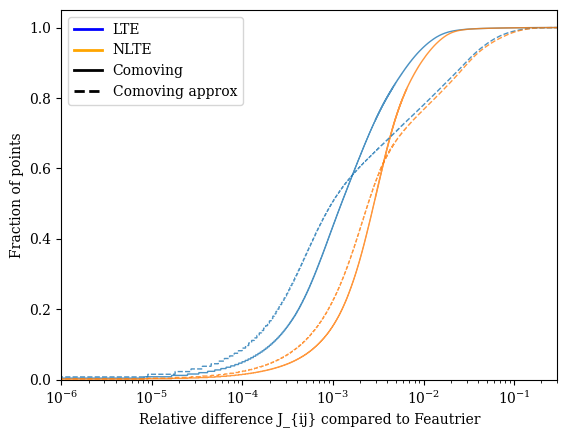

In [41]:
plt.figure()
plt.hist(rel_diff_comoving_original, cumulative=True, label='Comoving', density=True,
         bins=len(rel_diff_comoving), histtype='step', alpha=0.8)
plt.hist(rel_diff_NLTE_comoving, cumulative=True, label='Comoving NLTE', density=True,
         bins=len(rel_diff_comoving), histtype='step', alpha=0.8)
plt.gca().set_prop_cycle(None)
plt.hist(rel_diff_comapp_original, cumulative=True, label='Comoving approx', density=True,
         bins = len(rel_diff_comapp), histtype='step', ls = "--", alpha=0.8)
plt.hist(rel_diff_NLTE_comapp, cumulative=True, label='Comoving approx NLTE', density=True,
         bins = len(rel_diff_comapp), histtype='step', ls = "--", alpha=0.8)
plt.xscale('log')
# plt.xlim(1e-6,3e-1)
# plt.legend(loc = "upper left")
plt.xlim(1e-6,3e-1)
colors = ['blue', 'orange', 'black', 'black']
lines = [matplotlib.lines.Line2D([0], [0], color=c, linewidth=2, linestyle=ls) for c, ls in zip(colors, ['-', '-', '-', '--'])]
labels = ['LTE', 'NLTE', 'Comoving', 'Comoving approx']
plt.legend(lines, labels, loc = "upper left")
plt.xlabel("Relative difference J_{ij} compared to Feautrier")
plt.ylabel("Fraction of points")
# plt.legend(lines, labels, loc = "upper right")
# plt.title("Relative differences comoving solvers vs feautrier on original grid")
plt.savefig("Comparison_differences_comoving_implementations_LTE_NLTE.png")
plt.show()


In [42]:
#Also get some values for fraction of values below a certain accuracy threshold
threshold = 1e-2
print("Comoving: ", np.sum(rel_diff_comoving_original < threshold)/len(rel_diff_comoving_original))
print("Comoving approx: ", np.sum(rel_diff_comapp_original < threshold)/len(rel_diff_comapp_original))
print("Comoving NLTE: ", np.sum(rel_diff_NLTE_comoving < threshold)/len(rel_diff_NLTE_comoving))
print("Comoving approx NLTE: ", np.sum(rel_diff_NLTE_comapp < threshold)/len(rel_diff_NLTE_comapp))

Comoving:  0.9442767427704768
Comoving approx:  0.7800939806956739
Comoving NLTE:  0.9103061430760665
Comoving approx NLTE:  0.7667117259043186


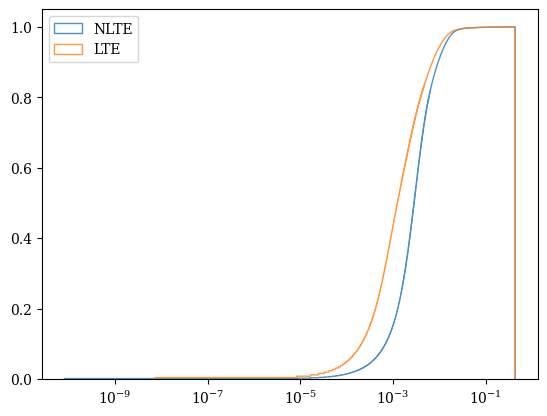

In [43]:
#err compare vs rel diffs in single iteration
plt.figure()
plt.hist(rel_diff_NLTE_comoving, cumulative=True, label='NLTE', density=True,
         bins=len(rel_diff_comoving), histtype='step', alpha=0.8)
plt.hist(rel_diff_comoving_original, cumulative=True, label='LTE', density=True,
         bins=len(rel_diff_comoving), histtype='step', alpha=0.8)
plt.xscale('log')
# plt.xlim(1e-6,3e-1)
plt.legend(loc = "upper left")
# plt.title("NLTE vs LTE relative differences comoving solver on original grid")
plt.show()

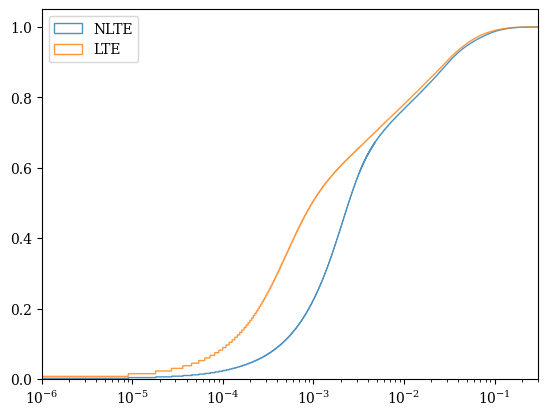

In [44]:
#compare comoving approx NLTE vs rel diffs in single iteration
plt.figure()
plt.hist(rel_diff_NLTE_comapp, cumulative=True, label='NLTE', density=True,
         bins=len(rel_diff_comoving), histtype='step', alpha=0.8)
plt.hist(rel_diff_comapp_original, cumulative=True, label='LTE', density=True,
         bins=len(rel_diff_comoving), histtype='step', alpha=0.8)
plt.xscale('log')
plt.xlim(1e-6,3e-1)
plt.legend(loc = "upper left")
# plt.title("NLTE vs LTE relative differences comoving approx solver on original grid")
plt.show()

Instead of the above, we might just need to interpolate the results instead onto the original grid.

In [45]:
from scipy.interpolate import LinearNDInterpolator, NearestNDInterpolator
# interp_func_J_gmsh = LinearNDInterpolator (position_gmsh, J_gmsh)
# interp_func_J_haar = LinearNDInterpolator (position_haar, J_haar)

#nearest neighbor interpolation, as the linear does not seem to work for the haar mesh...
# interp_func_J_gmsh = NearestNDInterpolator (position_gmsh, J_gmsh)
# interp_func_J_haar = NearestNDInterpolator (position_haar, J_haar)
interp_func_J_rec = NearestNDInterpolator (position_rec, J_rec)

# prj_J_gmsh_original = interp_func_J_gmsh(position_original)
# prj_J_haar_original = interp_func_J_haar(position_original)

In [46]:
prj_J_rec_original = interp_func_J_rec(position_original)

In [47]:
# print(prj_J_gmsh_original.shape)
# reldiff_gmsh_original_grid = 1.0/2.0*np.abs(prj_J_gmsh_original-J_original)/(prj_J_gmsh_original+J_original)
# reldiff_haar_original_grid = 1.0/2.0*np.abs(prj_J_haar_original-J_original)/(prj_J_haar_original+J_original)
reldiff_rec_original_grid = 1.0/2.0*np.abs(prj_J_rec_original-J_original)/(prj_J_rec_original+J_original)

In [48]:
# reldiff_original_gmsh = yt.load_unstructured_mesh(
#     connectivity = delaunay_original.simplices.astype(np.int64),
#     coordinates  = delaunay_original.points.astype(np.float64) * 100.0, # yt expects cm not m 
#     node_data    = {('connect1', 'J_reldiff'): reldiff_gmsh_original_grid[delaunay_original.simplices].astype(np.float64)}
# )
# sl = yt.SlicePlot (reldiff_original_gmsh, 'z', ('connect1','J_reldiff'))
# sl.set_cmap       (('connect1', 'J_reldiff'), 'magma')
# sl.set_zlim(('connect1', 'J_reldiff'), zmin=(1e-6, "1"), zmax=(4e-1, "1"))
# sl.zoom           (1.1)

In [49]:
# reldiff_original_gmsh = yt.load_unstructured_mesh(
#     connectivity = delaunay_original.simplices.astype(np.int64),
#     coordinates  = delaunay_original.points.astype(np.float64) * 100.0, # yt expects cm not m 
#     node_data    = {('connect1', 'J_reldiff'): reldiff_haar_original_grid[delaunay_original.simplices].astype(np.float64)}
# )
# sl = yt.SlicePlot (reldiff_original_gmsh, 'z', ('connect1','J_reldiff'))
# sl.set_cmap       (('connect1', 'J_reldiff'), 'magma')
# sl.set_zlim(('connect1', 'J_reldiff'), zmin=(1e-6, "1"), zmax=(4e-1, "1"))
# sl.zoom           (1.1)

yt : [INFO     ] 2025-01-14 13:03:28,149 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-01-14 13:03:28,150 Parameters: domain_dimensions         = [2 2 2]
yt : [INFO     ] 2025-01-14 13:03:28,151 Parameters: domain_left_edge          = [-4.10031269e+15 -4.10031269e+15 -4.09575680e+15]
yt : [INFO     ] 2025-01-14 13:03:28,152 Parameters: domain_right_edge         = [4.10031269e+15 4.10031269e+15 4.09575680e+15]
yt : [INFO     ] 2025-01-14 13:03:28,153 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-01-14 13:03:28,740 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 13:03:28,741 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 13:03:28,745 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 13:03:28,745 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2025-01-14 13:03:28,748 Making a fixed resolution buffer of (('connect1', 'J_re


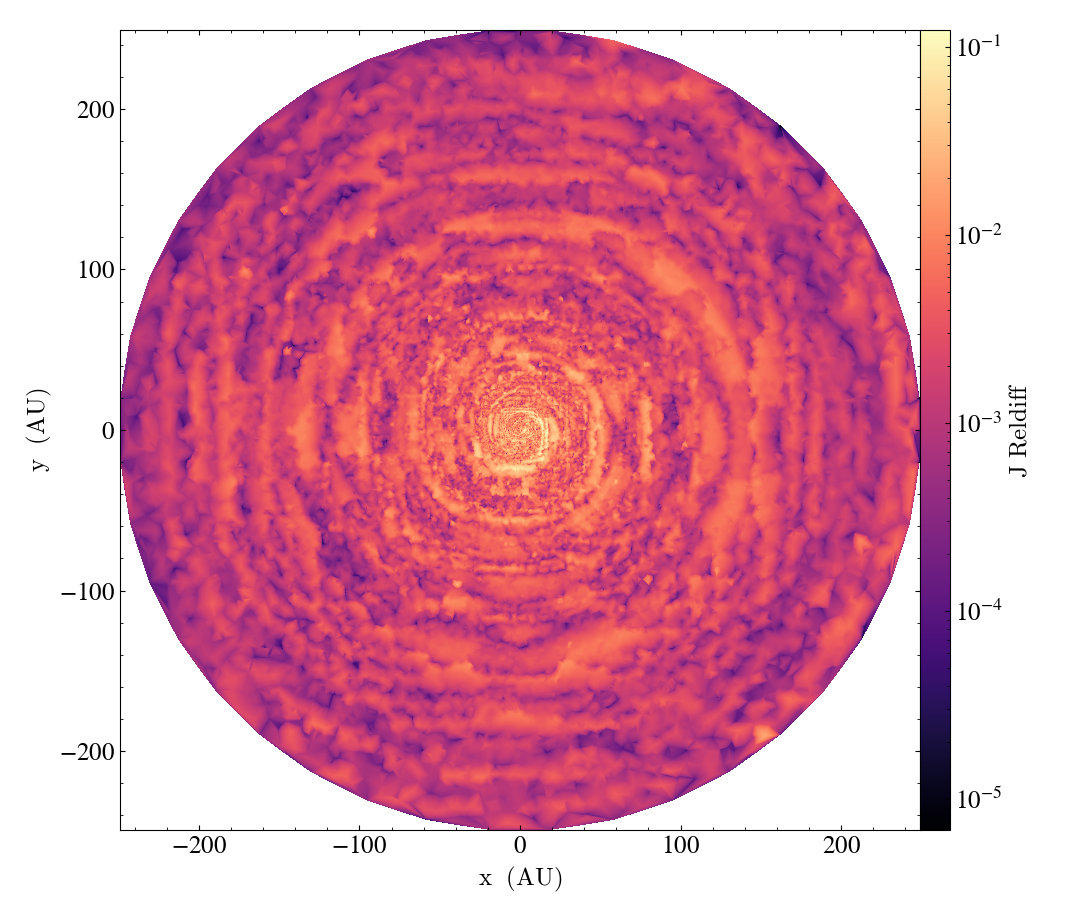

In [50]:
#checking the differences at the different remeshing settings
reldiff_original_rec = yt.load_unstructured_mesh(
    connectivity = delaunay_original.simplices.astype(np.int64),
    coordinates  = delaunay_original.points.astype(np.float64) * 100.0, # yt expects cm not m 
    node_data    = {('connect1', 'J_reldiff'): reldiff_rec_original_grid[delaunay_original.simplices].astype(np.float64)}
)
sl = yt.SlicePlot (reldiff_original_rec, 'z', ('connect1','J_reldiff'))
sl.set_cmap       (('connect1', 'J_reldiff'), 'magma')
# sl.set_zlim(('connect1', 'J_reldiff'), zmin=(1e-6, "1"), zmax=(4e-1, "1"))
sl.zoom           (1.1)